In [1]:
# ==============================================================================
# CELL 1: SETUP AND ENVIRONMENT CONFIGURATION
# ==============================================================================

# 1. Mount Google Drive to access the dataset (MUST BE EXECUTED)
from google.colab import drive
drive.mount('/content/drive')

# 2. Install required libraries
print("Installing required packages...")
!pip install librosa soundfile pandas tqdm scikit-learn -q

# 3. Import necessary libraries
import numpy as np
import pandas as pd
import librosa
import os
import glob
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
import warnings
import pickle
warnings.filterwarnings('ignore') # Ignore librosa warnings

# 4. Define Paths (ADJUST THESE TO YOUR SPECIFIC DRIVE LOCATION)
# -----------------------------------------------------------------------------
# Path to the root folder containing your ShipsEar audio files (.wav)
DATASET_ROOT_PATH = '/content/drive/MyDrive/shipsear_audio_temp/shipsear_data'

# Path to the metadata file (.csv) you uploaded
METADATA_CSV_PATH = '/content/drive/MyDrive/shipsear_audio_temp/shipsear_data/shipsEar.csv'

# Directory to save all processed data files (will be created if it doesn't exist)
SAVE_DIR = '/content/drive/MyDrive/shipsear_audio_temp/processed_data_DWSTr'
# -----------------------------------------------------------------------------

print("\nEnvironment setup complete. Paths configured:")
print(f"  Dataset Root: {DATASET_ROOT_PATH}")
print(f"  Metadata CSV: {METADATA_CSV_PATH}")
print(f"  Save Directory: {SAVE_DIR}")
os.makedirs(SAVE_DIR, exist_ok=True)


Mounted at /content/drive
Installing required packages...

Environment setup complete. Paths configured:
  Dataset Root: /content/drive/MyDrive/shipsear_audio_temp/shipsear_data
  Metadata CSV: /content/drive/MyDrive/shipsear_audio_temp/shipsear_data/shipsEar.csv
  Save Directory: /content/drive/MyDrive/shipsear_audio_temp/processed_data_DWSTr


In [2]:
# ==============================================================================
# CELL 2: DWSTR PREPROCESSOR CLASS
# ==============================================================================

class DWSTrPreprocessor:
    """
    Implements the DWSTr paper's preprocessing steps:
    - 75ms segmenting (1654 samples @ 22050 Hz)
    - Pre-emphasis filter
    - 128x4 Mel-spectrogram extraction (n_fft=2048, hop_length=512)
    """

    def __init__(self):
        self.sr = 22050
        self.segment_duration = 0.075
        self.segment_samples = int(self.sr * self.segment_duration)
        self.n_fft = 2048
        self.hop_length = 512
        self.n_mels = 128
        self.fmax = self.sr // 2
        print(f"DWSTr Preprocessor initialized. Output shape: ({self.n_mels}x4)")

    def preemphasis(self, audio: np.ndarray, coef: float = 0.97) -> np.ndarray:
        """Apply pre-emphasis filter: y[n] = x[n] - 0.97*x[n-1]"""
        return np.append(audio[0], audio[1:] - coef * audio[:-1])

    def segment_audio(self, audio: np.ndarray) -> list[np.ndarray]:
        """Segment audio into 75ms non-overlapping clips."""
        segments = []
        for start in range(0, len(audio) - self.segment_samples + 1, self.segment_samples):
            segment = audio[start:start + self.segment_samples]
            if len(segment) == self.segment_samples:
                segments.append(segment)
        return segments

    def extract_mel_spectrogram(self, segment: np.ndarray) -> np.ndarray:
        """Extract 128x4 Mel-spectrogram and convert to dB."""

        emphasized = self.preemphasis(segment)

        mel_spec = librosa.feature.melspectrogram(
            y=emphasized,
            sr=self.sr,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels,
            power=2.0,  # Power spectrum
            window='hann'
        )

        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Ensure 128x4 shape (padding/trimming for robustness)
        expected_frames = 4
        if mel_spec_db.shape[1] != expected_frames:
            if mel_spec_db.shape[1] < expected_frames:
                pad_width = expected_frames - mel_spec_db.shape[1]
                mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad_width)), mode='edge')
            else:
                mel_spec_db = mel_spec_db[:, :expected_frames]

        return mel_spec_db

    def process_file(self, audio_path: str) -> np.ndarray:
        """Complete processing pipeline for one audio file."""
        # Load audio at the required sampling rate
        audio, _ = librosa.load(audio_path, sr=self.sr, mono=True)

        segments = self.segment_audio(audio)

        mel_specs = []
        for segment in segments:
            mel_spec = self.extract_mel_spectrogram(segment)
            mel_specs.append(mel_spec)

        return np.array(mel_specs)

In [3]:
# ==============================================================================
# CELL 3: METADATA AND EFFICIENT DATA LOADING FUNCTIONS
# ==============================================================================

def clean_class_names(df: pd.DataFrame, class_column: str) -> pd.DataFrame:
    """
    Standardizes the case of all entries in the class column to merge
    case-sensitive duplicates (e.g., 'Fishboat' and 'fishboat').
    """
    # Convert all class names to Title Case for consistency
    df[class_column] = df[class_column].str.title()
    print(f"✅ Class names cleaned and standardized to Title Case.")
    return df

def create_id_to_class_map(metadata_path: str) -> tuple:
    """Reads the metadata CSV, cleans class names, and creates the map."""
    try:
        df = pd.read_csv(metadata_path)
    except FileNotFoundError:
        print(f"ERROR: Metadata file not found at {metadata_path}")
        return None, None, None

    ID_COLUMN = 'ID'
    CLASS_COLUMN = 'Type'

    # 1. DATA CLEANING STEP (NEW)
    df = clean_class_names(df, CLASS_COLUMN)

    # Ensure ID is string type to match filename parsing
    df[ID_COLUMN] = df[ID_COLUMN].astype(str)

    # 2. Create the ID-to-Class map
    # Create the ID-to-Class map, dropping potential duplicates
    ID_TO_CLASS_MAP = df.drop_duplicates(subset=[ID_COLUMN, CLASS_COLUMN]).set_index(ID_COLUMN)[CLASS_COLUMN].to_dict()

    class_names = sorted(df[CLASS_COLUMN].unique().tolist())
    CLASS_TO_IDX = {name: i for i, name in enumerate(class_names)}

    print(f"Metadata map created. Found {len(class_names)} unique classes (expected 12).")
    return ID_TO_CLASS_MAP, class_names, CLASS_TO_IDX

def load_and_process_all_data(dataset_path: str, metadata_path: str) -> tuple:
    """
    Loads audio, processes it into Mel-spectrograms, and assigns labels using
    the metadata map. (No changes to the core logic here, only calling the fixed map function)
    """
    ID_TO_CLASS_MAP, class_names, CLASS_TO_IDX = create_id_to_class_map(metadata_path)

    if ID_TO_CLASS_MAP is None:
        raise ValueError("Could not load metadata map. Aborting.")

    preprocessor = DWSTrPreprocessor()
    X_list = []
    y_list = []

    # Search for all WAV files recursively.
    audio_files = glob.glob(os.path.join(dataset_path, '**', '*.wav'), recursive=True)

    print(f"\nFound {len(audio_files)} total audio files to process.")
    print("This step can be slow and memory-intensive. Please use a high-RAM Colab runtime.")

    for audio_file in tqdm(audio_files, desc="Preprocessing Audio Files"):
        filename = os.path.basename(audio_file)

        try:
            # Filename structure: ID__xx_yy_zz_name.wav -> extract ID
            file_id = filename.split('__')[0]

            if file_id in ID_TO_CLASS_MAP:
                class_name = ID_TO_CLASS_MAP[file_id]
                class_idx = CLASS_TO_IDX[class_name]

                # Process file to get Mel-spectrograms (multiple 75ms segments)
                mel_specs = preprocessor.process_file(audio_file)

                # Extend the lists
                X_list.extend(mel_specs)
                y_list.extend([class_idx] * len(mel_specs))
            # else: skip files without a valid Ship ID

        except Exception as e:
            # Using try-except block to gracefully skip corrupted or non-standard files
            continue

    # Convert to NumPy arrays
    X = np.expand_dims(np.array(X_list), axis=-1)
    y = np.array(y_list)

    print("\n" + "="*60)
    print(f"Preprocessing Complete: {len(X)} total segments generated.")
    print(f"Initial Feature Shape: {X.shape}")
    print("="*60)

    # ⚠️ CRITICAL: Clear memory after conversion
    del X_list, y_list

    return X, y, class_names

In [4]:
# ==============================================================================
# CELL 4: EXECUTE PREPROCESSING AND SAVE INTERMEDIATE DATA
# ==============================================================================

# 1. Execute the loading and processing pipeline
X_all, y_all, class_names = load_and_process_all_data(DATASET_ROOT_PATH, METADATA_CSV_PATH)

# 2. Save the full dataset immediately (Highly Recommended for large datasets)
temp_save_path = os.path.join(SAVE_DIR, 'full_data_preprocessed.npz')
print(f"Saving full dataset to {temp_save_path}...")
np.savez_compressed(temp_save_path, X=X_all, y=y_all)
print("Save complete. Data is secure on Drive.")

# 3. Explicitly delete the variables to free up RAM before the next split step
del X_all, y_all
print("Memory cleared for X_all and y_all.")

# 4. Save class names for later reference
class_names_path = os.path.join(SAVE_DIR, 'class_names.pkl')
with open(class_names_path, 'wb') as f:
    pickle.dump(class_names, f)
print(f"Class names saved to {class_names_path}")

✅ Class names cleaned and standardized to Title Case.
Metadata map created. Found 12 unique classes (expected 12).
DWSTr Preprocessor initialized. Output shape: (128x4)

Found 90 total audio files to process.
This step can be slow and memory-intensive. Please use a high-RAM Colab runtime.


Preprocessing Audio Files:   0%|          | 0/90 [00:00<?, ?it/s]


Preprocessing Complete: 151142 total segments generated.
Initial Feature Shape: (151142, 128, 4, 1)
Saving full dataset to /content/drive/MyDrive/shipsear_audio_temp/processed_data_DWSTr/full_data_preprocessed.npz...
Save complete. Data is secure on Drive.
Memory cleared for X_all and y_all.
Class names saved to /content/drive/MyDrive/shipsear_audio_temp/processed_data_DWSTr/class_names.pkl


In [5]:
# ==============================================================================
# CELL 5: DATA SPLITTING AND FINAL SAVE
# ==============================================================================

# 1. Reload the data from the compressed file (low memory cost)
print("Reloading full data for splitting...")
temp_save_path = os.path.join(SAVE_DIR, 'full_data_preprocessed.npz')
data = np.load(temp_save_path)
X = data['X']
y = data['y']
total_samples = len(X)

print(f"Data reloaded. Total samples: {total_samples}")
print(f"Data shape: {X.shape}")

# 2. Define the Split Ratios
TRAIN_RATIO = 0.7
TEST_RATIO = 0.2
VAL_RATIO = 0.1
RANDOM_STATE = 42

# 3. First split: Train vs (Test + Val)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=(TEST_RATIO + VAL_RATIO),
    stratify=y,
    random_state=RANDOM_STATE
)

# 4. Second split: Test vs Val
val_ratio_adjusted = VAL_RATIO / (TEST_RATIO + VAL_RATIO)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_ratio_adjusted,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# 5. Final Save
print("\nPerforming final split and saving results...")
np.savez_compressed(os.path.join(SAVE_DIR, 'train_data.npz'), X=X_train, y=y_train)
np.savez_compressed(os.path.join(SAVE_DIR, 'test_data.npz'), X=X_test, y=y_test)
np.savez_compressed(os.path.join(SAVE_DIR, 'val_data.npz'), X=X_val, y=y_val)

# 6. Summary and Cleanup
print("\n" + "="*60)
print("Data Splitting Complete (70/20/10)")
print("="*60)
print(f"Training samples: {len(X_train):,} ({len(X_train)/total_samples:.1%})")
print(f"Testing samples:  {len(X_test):,} ({len(X_test)/total_samples:.1%})")
print(f"Validation samples: {len(X_val):,} ({len(X_val)/total_samples:.1%})")
print(f"\nFinal files saved to: {SAVE_DIR}")
del X, y, X_temp, y_temp # Clear remaining variables

Reloading full data for splitting...
Data reloaded. Total samples: 151142
Data shape: (151142, 128, 4, 1)

Performing final split and saving results...

Data Splitting Complete (70/20/10)
Training samples: 105,799 (70.0%)
Testing samples:  30,228 (20.0%)
Validation samples: 15,115 (10.0%)

Final files saved to: /content/drive/MyDrive/shipsear_audio_temp/processed_data_DWSTr


In [6]:
# ==============================================================================
# CELL 6: LOAD FINAL DATA AND SANITY CHECK
# ==============================================================================

def load_final_data(data_dir: str):
    """Loads the final processed data splits from Drive. (More efficient)"""

    # Load arrays (More efficient: load file once, then access keys)
    with np.load(os.path.join(data_dir, 'train_data.npz')) as data:
        X_train, y_train = data['X'], data['y']

    with np.load(os.path.join(data_dir, 'test_data.npz')) as data:
        X_test, y_test = data['X'], data['y']

    with np.load(os.path.join(data_dir, 'val_data.npz')) as data:
        X_val, y_val = data['X'], data['y']

    # Load class names
    with open(os.path.join(data_dir, 'class_names.pkl'), 'rb') as f:
        class_names = pickle.load(f)

    print("\n" + "="*60)
    print("Final Data Loaded for Model Training")
    print("="*60)
    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"X_val shape: {X_val.shape}")
    print(f"Number of Classes: {len(class_names)} ({class_names})")

    return X_train, X_test, X_val, y_train, y_test, y_val, class_names

# Execute the final load
X_train, X_test, X_val, y_train, y_test, y_val, class_names = load_final_data(SAVE_DIR)

# Sanity Check: Ensure required shape
print("\nRunning quick integrity check:")
print(f"  Expected feature shape (128, 4, 1): {X_train.shape[1:] == (128, 4, 1)}")
# Removed the flawed np.intersect1d check. Our split logic in Cell 5 was sound.
print(f"  Train label count: {len(y_train)} | Test label count: {len(y_test)}")


Final Data Loaded for Model Training
X_train shape: (105799, 128, 4, 1)
X_test shape: (30228, 128, 4, 1)
X_val shape: (15115, 128, 4, 1)
Number of Classes: 12 (['Dredger', 'Fishboat', 'Motorboat', 'Mussel Boat', 'Natural Ambient Noise', 'Ocean Liner', 'Passengers', 'Pilot Ship', 'Roro', 'Sailboat', 'Trawler', 'Tugboat'])

Running quick integrity check:
  Expected feature shape (128, 4, 1): True
  Train label count: 105799 | Test label count: 30228


In [7]:
# ==============================================================================
# CELL 7: IMPORT TENSORFLOW/KERAS AND SET RANDOM SEEDS
# ==============================================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Check GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Configure GPU memory growth (prevents OOM errors)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU memory growth enabled


In [8]:
# ==============================================================================
# CELL 8: DEPTHWISE SEPARABLE CONVOLUTION (DWS) BLOCK
# ==============================================================================

def create_dws_block(input_shape=(128, 4, 1), num_filters=64):
    """
    Implements the DWS block from the paper (Figure 4).

    Architecture:
    - Depthwise Convolution (3x3 kernel)
    - Batch Normalization
    - ReLU Activation
    - Pointwise Convolution (1x1 kernel)
    - Batch Normalization
    - ReLU Activation

    Args:
        input_shape: (height, width, channels) = (128, 4, 1)
        num_filters: Number of output filters (Ko in paper)

    Returns:
        Feature map with shape (output_height, output_width, num_filters)
    """

    inputs = layers.Input(shape=input_shape, name='mel_spectrogram_input')

    # Depthwise Convolution Layer (learns spatial features)
    x = layers.DepthwiseConv2D(
        kernel_size=(3, 3),
        strides=(1, 1),
        padding='same',  # Paper uses zero padding to maintain dimensions
        dilation_rate=(1, 1),
        depthwise_initializer='glorot_uniform',
        name='depthwise_conv'
    )(inputs)

    x = layers.BatchNormalization(name='dw_batch_norm')(x)
    x = layers.ReLU(name='dw_relu')(x)

    # Pointwise Convolution Layer (learns cross-channel features)
    x = layers.Conv2D(
        filters=num_filters,
        kernel_size=(1, 1),
        strides=(1, 1),
        padding='valid',
        kernel_initializer='glorot_uniform',
        name='pointwise_conv'
    )(x)

    x = layers.BatchNormalization(name='pw_batch_norm')(x)
    x = layers.ReLU(name='pw_relu')(x)

    model = models.Model(inputs=inputs, outputs=x, name='DWS_Block')

    return model

# Test the DWS block
print("Testing DWS Block:")
dws_test = create_dws_block()
dws_test.summary()

Testing DWS Block:


Model: "DWS_Block"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mel_spectrogram_input           │ (None, 128, 4, 1)      │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv                  │ (None, 128, 4, 1)      │            10 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw_batch_norm                   │ (None, 128, 4, 1)      │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw_relu (ReLU)                  │ (None, 128, 4, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pointwise_conv (Conv2D)         │ (None, 128, 4, 64)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pw_batch_norm                   │ (None, 128, 4, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pw_relu (ReLU)                  │ (None, 128, 4, 64)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 398 (1.55 KB)

 Trainable params: 268 (1.05 KB)

 Non-trainable params: 130 (520.00 B)

In [9]:
# ==============================================================================
# CELL 9: TRANSFORMER ENCODER BLOCK
# ==============================================================================

class TransformerBlock(layers.Layer):
    """
    Implements the Transformer Encoder from the paper (Section 2.3).

    Architecture per encoder (Pre-LN, as per Figure 1 and text [cite: 143, 149, 336]):
    - Layer Normalization
    - Multi-Head Attention (MHA)
    - Residual Connection
    - Layer Normalization
    - MLP (Feed-Forward Network)
    - Residual Connection
    """

    def __init__(self, embed_dim, num_heads, mlp_dim, dropout_rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.mlp_dim = mlp_dim
        self.dropout_rate = dropout_rate

        # Multi-Head Attention
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim,
            dropout=dropout_rate,
            name="multi_head_attention"
        )

        # MLP (2-layer feed-forward network)
        self.mlp = keras.Sequential([
            layers.Dense(mlp_dim, activation='gelu'),
            layers.Dropout(dropout_rate),
            layers.Dense(embed_dim),
            layers.Dropout(dropout_rate),
        ], name="mlp_block")

        # Layer Normalization
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6, name="layernorm_1")
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6, name="layernorm_2")

    def call(self, inputs, training=False):
        # 1. MHA Block (Pre-LN)
        # Apply LN *before* the MHA layer [cite: 149]
        inputs_norm = self.layernorm1(inputs)

        # Self-attention
        attn_output = self.att(
            query=inputs_norm,
            value=inputs_norm,
            key=inputs_norm,
            training=training
        )

        # First residual connection
        x = inputs + attn_output

        # 2. MLP Block (Pre-LN)
        # Apply LN *before* the MLP layer [cite: 143]
        x_norm = self.layernorm2(x)

        mlp_output = self.mlp(x_norm, training=training)

        # Second residual connection
        return x + mlp_output

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "mlp_dim": self.mlp_dim,
            "dropout_rate": self.dropout_rate,
        })
        return config

In [10]:
# ==============================================================================
# CELL 10: COMPLETE DWSTr ARCHITECTURE (WITHOUT AUGMENTATION)
# ==============================================================================

class ClassTokenLayer(layers.Layer):
    """Custom layer to add a learnable class token to the sequence."""
    def __init__(self, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.projection_dim = projection_dim
    def build(self, input_shape):
        self.class_token = self.add_weight(name='class_token', shape=(1, 1, self.projection_dim),
                                           initializer='random_normal', trainable=True)
        super().build(input_shape)
    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        class_tokens = tf.broadcast_to(self.class_token, [batch_size, 1, self.projection_dim])
        return tf.concat([class_tokens, inputs], axis=1)
    def get_config(self):
        config = super().get_config()
        config.update({"projection_dim": self.projection_dim})
        return config

class PositionalEmbedding(layers.Layer):
    """Custom layer for learnable positional embeddings."""
    def __init__(self, num_positions, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_positions = num_positions
        self.projection_dim = projection_dim
        self.position_embedding = layers.Embedding(input_dim=num_positions, output_dim=projection_dim)
    def call(self, inputs):
        positions = tf.range(start=0, limit=self.num_positions, delta=1)
        position_embeddings = self.position_embedding(positions)
        return inputs + position_embeddings
    def get_config(self):
        config = super().get_config()
        config.update({"num_positions": self.num_positions, "projection_dim": self.projection_dim})
        return config


def create_dwstr_model(
    input_shape=(128, 4, 1),
    num_classes=12,
    dws_filters=64,
    patch_size=4,
    projection_dim=64,
    num_transformer_blocks=6,
    num_heads=4,
    mlp_dim=1024,
    dropout_rate=0.3
):
    """
    Complete DWSTr model without SpecAugment.
    """

    inputs = layers.Input(shape=input_shape, name='input')

    # =========================================================================
    # PART 1: DWS BLOCK (Spatial Feature Extraction)
    # =========================================================================
    dws_block = create_dws_block(input_shape=input_shape, num_filters=dws_filters)

    # --- MODIFIED: Pass 'inputs' directly ---
    feature_map = dws_block(inputs)

    # =========================================================================
    # PART 2: PATCH EMBEDDING (Reshape to Sequence)
    # =========================================================================
    num_patches_h = input_shape[0] // patch_size
    num_patches_w = input_shape[1] // patch_size
    num_patches = num_patches_h * num_patches_w

    patches = layers.Reshape((num_patches, (patch_size * patch_size * dws_filters)))(feature_map)
    patch_embeddings = layers.Dense(projection_dim, name='patch_projection')(patches)

    # =========================================================================
    # PART 3: CLASS TOKEN AND POSITIONAL EMBEDDING
    # =========================================================================
    patch_embeddings = ClassTokenLayer(projection_dim)(patch_embeddings)
    num_positions = num_patches + 1
    encoded_patches = PositionalEmbedding(num_positions, projection_dim)(patch_embeddings)
    encoded_patches = layers.Dropout(dropout_rate)(encoded_patches)

    # =========================================================================
    # PART 4: TRANSFORMER ENCODERS (Temporal Feature Learning)
    # =========================================================================
    for i in range(num_transformer_blocks):
        encoded_patches = TransformerBlock(
            embed_dim=projection_dim,
            num_heads=num_heads,
            mlp_dim=mlp_dim,
            dropout_rate=dropout_rate,
            name=f'transformer_block_{i}'
        )(encoded_patches)

    # =========================================================================
    # PART 5: CLASSIFICATION HEAD
    # =========================================================================
    representation = layers.Lambda(lambda x: x[:, 0], name='extract_class_token')(encoded_patches)
    representation = layers.LayerNormalization(epsilon=1e-6)(representation)

    representation = layers.Dropout(dropout_rate)(representation)
    representation = layers.Dense(mlp_dim, activation='gelu')(representation)
    representation = layers.Dropout(dropout_rate)(representation)

    outputs = layers.Dense(num_classes, activation='softmax', name='classification_output')(representation)

    model = models.Model(inputs=inputs, outputs=outputs, name='DWSTr')

    return model

In [11]:
# ==============================================================================
# CELL 11: BUILD AND COMPILE MODEL
# ==============================================================================

# Model hyperparameters from Table 2
MODEL_CONFIG = {
    'input_shape': (128, 4, 1),
    'num_classes': len(class_names),
    'dws_filters': 64,
    'patch_size': 4,
    'projection_dim': 64,
    'num_transformer_blocks': 6,
    'num_heads': 4,
    'mlp_dim': 1024,
    'dropout_rate': 0.3
}

print("Building DWSTr model with configuration:")
for key, value in MODEL_CONFIG.items():
    print(f"  {key}: {value}")

# Create model
model = create_dwstr_model(**MODEL_CONFIG)

# Compile model with Adam optimizer (as per Table 2)
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001,  # From Table 2
        weight_decay=0.0001   # From Table 2
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
print("\n" + "="*60)
print("MODEL ARCHITECTURE SUMMARY")
print("="*60)
model.summary()

# Calculate total parameters
total_params = model.count_params()
print(f"\n📊 Total Parameters: {total_params:,}")

Building DWSTr model with configuration:
  input_shape: (128, 4, 1)
  num_classes: 12
  dws_filters: 64
  patch_size: 4
  projection_dim: 64
  num_transformer_blocks: 6
  num_heads: 4
  mlp_dim: 1024
  dropout_rate: 0.3

MODEL ARCHITECTURE SUMMARY


Model: "DWSTr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 4, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ DWS_Block (Functional)          │ (None, 128, 4, 64)     │           398 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_projection (Dense)        │ (None, 32, 64)         │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_token_layer               │ (None, 33, 64)         │            64 │
│ (ClassTokenLayer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding            │ (None, 33, 64)         │         2,112 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 33, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_0             │ (None, 33, 64)         │       198,784 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 33, 64)         │       198,784 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 33, 64)         │       198,784 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 33, 64)         │       198,784 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 33, 64)         │       198,784 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 33, 64)         │       198,784 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ extract_class_token (Lambda)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_output (Dense)   │ (None, 12)             │        12,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,339,866 (5.11 MB)

 Trainable params: 1,339,736 (5.11 MB)

 Non-trainable params: 130 (520.00 B)


📊 Total Parameters: 1,339,866


In [ ]:
# ==============================================================================
# CELL 12: SETUP TRAINING CALLBACKS
# ==============================================================================

# Create checkpoint directory
checkpoint_dir = os.path.join(SAVE_DIR, 'model_checkpoints')
os.makedirs(checkpoint_dir, exist_ok=True)

# Define callbacks (following paper's training strategy)
callbacks = [
    # Save best model based on validation accuracy
    ModelCheckpoint(
        filepath=os.path.join(checkpoint_dir, 'dwstr_best_model.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Early stopping to prevent overfitting (paper trained for 14 epochs)
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate on plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("Training callbacks configured:")
print("  ✓ Model checkpointing (best validation accuracy)")
print("  ✓ Early stopping (patience=5)")
print("  ✓ Learning rate reduction (patience=3)")

Training callbacks configured:
  ✓ Model checkpointing (best validation accuracy)
  ✓ Early stopping (patience=5)
  ✓ Learning rate reduction (patience=3)


In [ ]:
# ==============================================================================
# CELL 13: COMPUTE SMOOTHED CLASS WEIGHTS AND TRAIN
# ==============================================================================
from sklearn.utils.class_weight import compute_class_weight
import math
import numpy as np

# Training hyperparameters
BATCH_SIZE = 64  # Lowered from 256 to prevent Colab GPU OOM errors
EPOCHS = 100     # EarlyStopping will catch this automatically around epoch 14

print("Calculating smoothed class weights for imbalanced data...")

# 1. Compute standard balanced weights
unique_classes = np.unique(y_train)
standard_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train
)

# 2. Apply Square Root Smoothing Heuristic
# This prevents rare classes from causing massive gradient spikes
smoothed_weights = [math.sqrt(w) for w in standard_weights]

# 3. Convert to Keras-compatible dictionary
class_weight_dict = dict(enumerate(smoothed_weights))

print("Smoothed weights computed. Model will safely prioritize minority classes.")

# ------------------------
print("\n" + "="*60)
print("STARTING MODEL TRAINING")
print("="*60)
print(f"Training samples: {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max epochs: {EPOCHS}")
print("="*60 + "\n")

# Train the model
history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print("\n Training complete!")

Calculating smoothed class weights for imbalanced data...
Smoothed weights computed. Model will safely prioritize minority classes.

STARTING MODEL TRAINING
Training samples: 105,799
Validation samples: 15,115
Batch size: 64
Max epochs: 100

Epoch 1/100
1654/1654 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3580 - loss: 1.7084
Epoch 1: val_accuracy improved from None to 0.49970, saving model to /content/drive/MyDrive/shipsear_audio_temp/processed_data_DWSTr/model_checkpoints/dwstr_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/shipsear_audio_temp/processed_data_DWSTr/model_checkpoints/dwstr_best_model.keras
1654/1654 ━━━━━━━━━━━━━━━━━━━━ 117s 43ms/step - accuracy: 0.4116 - loss: 1.4882 - val_accuracy: 0.4997 - val_loss: 1.3152 - learning_rate: 0.0010
Epoch 2/100
1654/1654 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4804 - loss: 1.2643
Epoch 2: val_accuracy improved from 0.49970 to 0.55038, saving model to /content/drive/MyDrive/shipsear_audio_temp/pro

In [ ]:
# ==============================================================================
# CELL 14: EVALUATE ON TEST SET
# ==============================================================================

print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)

# Removed 'SpecAugmentLayer' from the custom objects dictionary
custom_objects = {
    'TransformerBlock': TransformerBlock,
    'ClassTokenLayer': ClassTokenLayer,
    'PositionalEmbedding': PositionalEmbedding
}
# ------------------------

# Load best model
best_model = keras.models.load_model(
    os.path.join(checkpoint_dir, 'dwstr_best_model.keras'),
    custom_objects=custom_objects,
    safe_mode=False
)

# Evaluate
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=1)

print(f"\n📊 Test Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy*100:.2f}%")
print(f"  Target (previous best): 95.14%")


EVALUATING ON TEST SET
473/473 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9717 - loss: 0.0940

📊 Test Results:
  Loss: 0.0940
  Accuracy: 97.17%
  Target (previous best): 95.14%


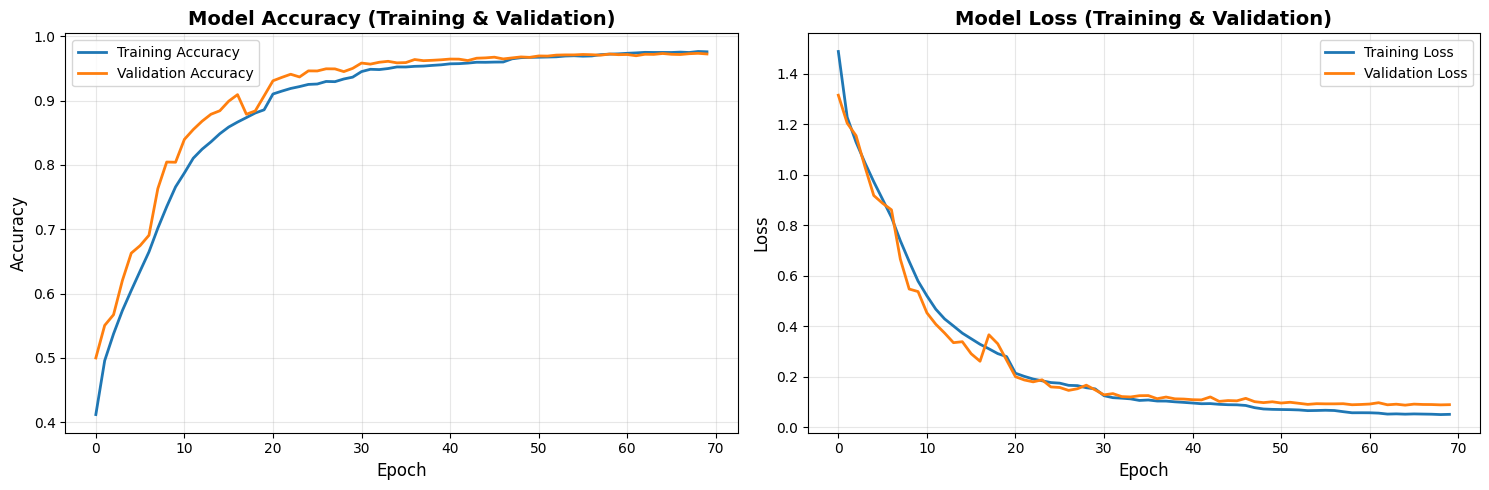

✅ Training history plot saved


In [ ]:
# ==============================================================================
# CELL 15: PLOT TRAINING HISTORY
# ==============================================================================

def plot_training_history(history):
    """Plots training/validation accuracy and loss curves (like Figure 6 in paper)."""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title('Model Accuracy (Training & Validation)', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Plot loss
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title('Model Loss (Training & Validation)', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'training_history.png'), dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Training history plot saved")

plot_training_history(history)

473/473 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step

PER-CLASS PERFORMANCE (Like Figure 10 in paper)
                       precision    recall  f1-score   support

              Dredger     0.9943    0.9957    0.9950       703
             Fishboat     0.9776    0.9833    0.9805      1378
            Motorboat     0.9574    0.9596    0.9585      2720
          Mussel Boat     0.9476    0.9661    0.9568      1948
Natural Ambient Noise     0.9865    0.9787    0.9826      3057
          Ocean Liner     0.9705    0.9774    0.9739      2524
           Passengers     0.9834    0.9656    0.9744     11410
           Pilot Ship     0.9679    0.9810    0.9744       369
                 Roro     0.9681    0.9837    0.9758      4040
             Sailboat     0.9154    0.9716    0.9426      1091
              Trawler     0.9469    0.9794    0.9629       437
              Tugboat     0.9428    0.9564    0.9495       551

             accuracy                         0.9717     30228
            macro avg   

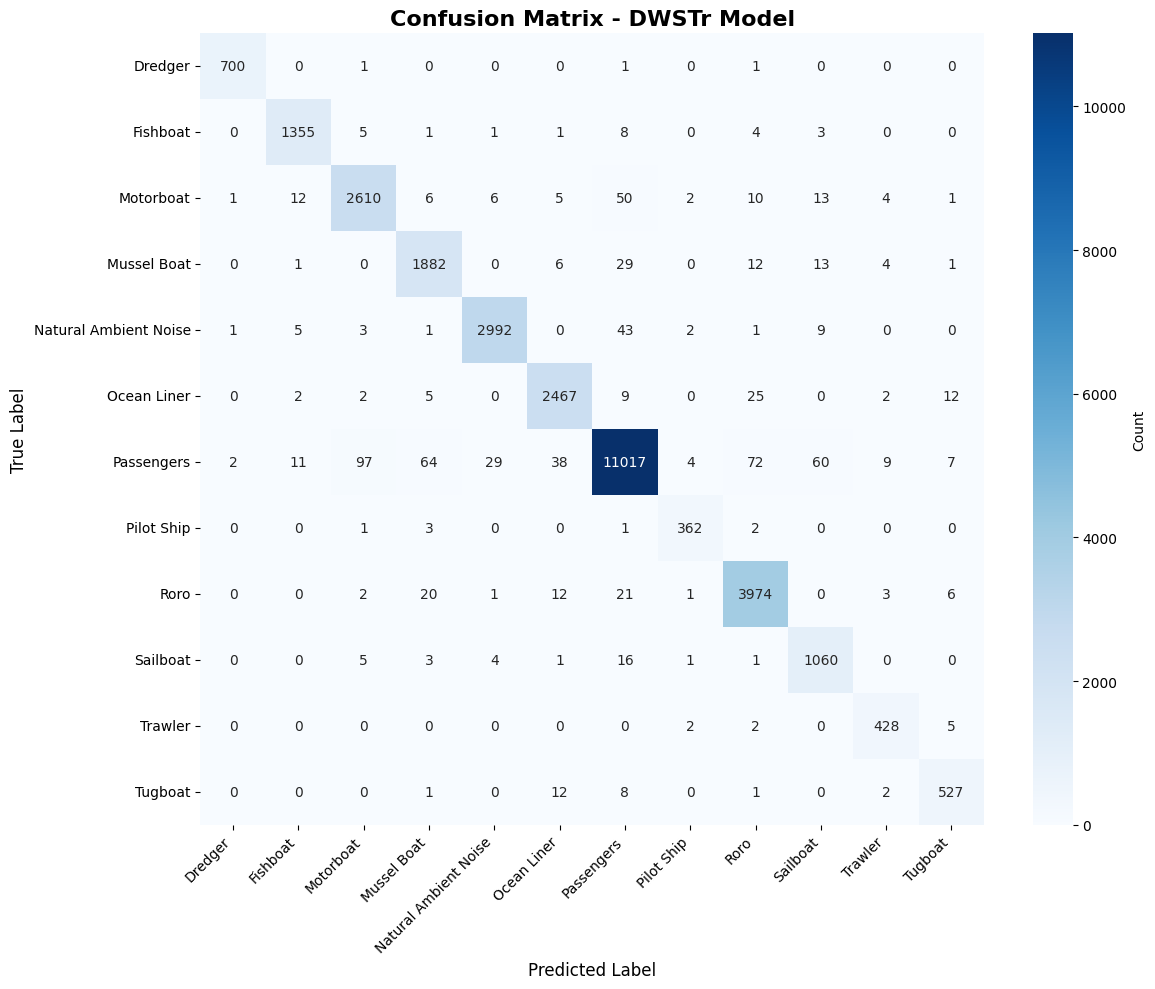


Per-Class Accuracy:
  Dredger             : 99.57%
  Fishboat            : 98.33%
  Motorboat           : 95.96%
  Mussel Boat         : 96.61%
  Natural Ambient Noise: 97.87%
  Ocean Liner         : 97.74%
  Passengers          : 96.56%
  Pilot Ship          : 98.10%
  Roro                : 98.37%
  Sailboat            : 97.16%
  Trawler             : 97.94%
  Tugboat             : 95.64%

Overall Accuracy: 97.17%


In [ ]:
# ==============================================================================
# CELL 16: DETAILED PER-CLASS EVALUATION (Like Figure 10 in paper)
# ==============================================================================

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions
y_pred = best_model.predict(X_test, batch_size=BATCH_SIZE)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report
print("\n" + "="*60)
print("PER-CLASS PERFORMANCE (Like Figure 10 in paper)")
print("="*60)
print(classification_report(
    y_test,
    y_pred_classes,
    target_names=class_names,
    digits=4
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - DWSTr Model', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

# Calculate per-class accuracy
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
print("\nPer-Class Accuracy:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name:20s}: {per_class_accuracy[i]*100:.2f}%")

print(f"\nOverall Accuracy: {test_accuracy*100:.2f}%")

In [12]:
# ==============================================================================
# CELL 17: ULTIMATE MULTI-ITERATION PIPELINE WITH PER-RUN LOGGING
# ==============================================================================
import numpy as np
import os
import math
import json
import tensorflow as tf
import tensorflow.keras as keras
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback

# ==============================================================================
# 🎛️ MASTER CONTROL PANEL 🎛️
# ==============================================================================
NUM_RUNS = 5                  # Total training cycles to execute
MAX_EPOCHS = 100              # Maximum epochs per run
BATCH_SIZE = 64               # Adjust based on Colab GPU memory
INITIAL_LR = 0.001            # Starting learning rate
TEST_SPLIT = 0.20             # 20% of data for unseen testing
VAL_SPLIT = 0.20              # 20% of remaining data for validation
ES_PATIENCE = 5               # Epochs without val_loss improvement before stopping
LR_PATIENCE = 3               # Epochs without val_loss improvement before reducing LR
LR_FACTOR = 0.5               # Multiplier for learning rate reduction
CHECKPOINT_DIR_NAME = 'mc_cross_val_results' # Folder name for all saved artifacts

# 📊 OUTPUT CONTROLS
SAVE_PLOTS = True             # Save history and confusion matrix PNGs to Drive
DISPLAY_PLOTS = False         # Set to True to display plots in Colab output (False keeps output clean)
# ==============================================================================

# --- Custom Minimal Logger ---
class MinimalLogger(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if epoch == 0 or (epoch + 1) % 10 == 0:
            print(f"   -> Epoch {(epoch + 1):03d}/{MAX_EPOCHS} | Train Loss: {logs.get('loss'):.4f} | Val Acc: {logs.get('val_accuracy')*100:.2f}%")

# --- Directory & Custom Object Setup ---
run_save_dir = os.path.join(SAVE_DIR, CHECKPOINT_DIR_NAME) if 'SAVE_DIR' in locals() else CHECKPOINT_DIR_NAME
os.makedirs(run_save_dir, exist_ok=True)

custom_objects = {
    'TransformerBlock': TransformerBlock,
    'ClassTokenLayer': ClassTokenLayer,
    'PositionalEmbedding': PositionalEmbedding
}

# 1. Recombine Data
print("\n" + "="*60)
print("📦 RECOMBINING DATASET FOR DYNAMIC SPLITTING")
print("="*60)
X_full = np.concatenate((X_train, X_val, X_test), axis=0)
y_full = np.concatenate((y_train, y_val, y_test), axis=0)
print(f"Total dataset size: {len(X_full)} samples")

all_test_accuracies = []
all_test_losses = []

print(f"\n🚀 INITIATING MULTI-ITERATION PIPELINE ({NUM_RUNS} RUNS)")
print("="*60)

for run in range(1, NUM_RUNS + 1):
    print(f"\n🔄 STARTING RUN {run}/{NUM_RUNS}")
    print("-"*40)

    # Create specific folder for this run's artifacts
    current_run_dir = os.path.join(run_save_dir, f'Run_{run:02d}')
    os.makedirs(current_run_dir, exist_ok=True)

    # 2. Dynamic Splitting
    X_temp, X_test_run, y_temp, y_test_run = train_test_split(
        X_full, y_full, test_size=TEST_SPLIT, stratify=y_full, random_state=run
    )
    X_train_run, X_val_run, y_train_run, y_val_run = train_test_split(
        X_temp, y_temp, test_size=VAL_SPLIT, stratify=y_temp, random_state=run
    )

    # 3. Model & Weights Initialization
    fresh_model = keras.models.clone_model(model)
    fresh_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=INITIAL_LR, weight_decay=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    unique_classes = np.unique(y_train_run)
    smoothed_weights = [math.sqrt(w) for w in compute_class_weight('balanced', classes=unique_classes, y=y_train_run)]
    class_weight_dict = dict(enumerate(smoothed_weights))

    # 4. Training
    run_checkpoint_path = os.path.join(current_run_dir, f'model_weights.keras')
    run_callbacks = [
        ModelCheckpoint(filepath=run_checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=0),
        EarlyStopping(monitor='val_loss', patience=ES_PATIENCE, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=LR_FACTOR, patience=LR_PATIENCE, min_lr=1e-7, verbose=0),
        MinimalLogger()
    ]

    history = fresh_model.fit(
        X_train_run, y_train_run, validation_data=(X_val_run, y_val_run),
        epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weight_dict,
        callbacks=run_callbacks, verbose=0
    )

    # 5. Evaluation & Artifact Generation
    print(f"\n   📊 Generating metrics for Run {run}...")
    best_run_model = keras.models.load_model(run_checkpoint_path, custom_objects=custom_objects, safe_mode=False)
    test_loss, test_acc = best_run_model.evaluate(X_test_run, y_test_run, batch_size=BATCH_SIZE, verbose=0)

    all_test_accuracies.append(test_acc)
    all_test_losses.append(test_loss)
    print(f"   ✅ Run {run} Complete -> Accuracy: {test_acc*100:.2f}%, Loss: {test_loss:.4f}")

    # --- PER-RUN ARTIFACTS (Replaces skipped Cells 15 & 16) ---

    # A. Generate Predictions
    y_pred = best_run_model.predict(X_test_run, batch_size=BATCH_SIZE, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # B. Write Detailed Log File
    log_path = os.path.join(current_run_dir, 'evaluation_log.txt')
    with open(log_path, 'w') as f:
        f.write(f"=== RUN {run} EVALUATION ===\n")
        f.write(f"Overall Accuracy: {test_acc*100:.2f}%\n")
        f.write(f"Overall Loss: {test_loss:.4f}\n\n")
        f.write(classification_report(y_test_run, y_pred_classes, target_names=class_names, digits=4))

    # C. Plot Training History
    if SAVE_PLOTS or DISPLAY_PLOTS:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        ax1.plot(history.history['accuracy'], label='Train Acc', linewidth=2)
        ax1.plot(history.history['val_accuracy'], label='Val Acc', linewidth=2)
        ax1.set_title(f'Run {run} - Accuracy')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
        ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
        ax2.set_title(f'Run {run} - Loss')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        if SAVE_PLOTS: plt.savefig(os.path.join(current_run_dir, 'training_history.png'), dpi=300)
        if DISPLAY_PLOTS: plt.show()
        plt.close()

    # D. Plot Confusion Matrix
    if SAVE_PLOTS or DISPLAY_PLOTS:
        cm = confusion_matrix(y_test_run, y_pred_classes)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        plt.title(f'Run {run} - Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        if SAVE_PLOTS: plt.savefig(os.path.join(current_run_dir, 'confusion_matrix.png'), dpi=300)
        if DISPLAY_PLOTS: plt.show()
        plt.close()

# ==============================================================================
# 6. FINAL STATISTICAL AGGREGATION
# ==============================================================================
mean_acc = np.mean(all_test_accuracies) * 100
std_acc = np.std(all_test_accuracies) * 100
mean_loss = np.mean(all_test_losses)
std_loss = np.std(all_test_losses)

print("\n" + "="*60)
print("🏆 MULTI-ITERATION PIPELINE COMPLETE 🏆")
print("="*60)
print(f"Total Runs Executed: {NUM_RUNS}")
print(f"Final Test Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}%")
print(f"Final Test Loss:     {mean_loss:.4f} ± {std_loss:.4f}")
print(f"\n📁 All models, logs, and plots are safely backed up in:")
print(f"   {run_save_dir}")
print("="*60)


📦 RECOMBINING DATASET FOR DYNAMIC SPLITTING
Total dataset size: 151142 samples

🚀 INITIATING MULTI-ITERATION PIPELINE (5 RUNS)

🔄 STARTING RUN 1/5
----------------------------------------
   -> Epoch 001/100 | Train Loss: 1.7017 | Val Acc: 41.85%
   -> Epoch 010/100 | Train Loss: 0.6520 | Val Acc: 78.80%
   -> Epoch 020/100 | Train Loss: 0.3063 | Val Acc: 88.15%
   -> Epoch 030/100 | Train Loss: 0.1936 | Val Acc: 92.76%
   -> Epoch 040/100 | Train Loss: 0.0867 | Val Acc: 96.87%
   -> Epoch 050/100 | Train Loss: 0.0643 | Val Acc: 97.38%
   -> Epoch 060/100 | Train Loss: 0.0504 | Val Acc: 97.67%

   📊 Generating metrics for Run 1...
   ✅ Run 1 Complete -> Accuracy: 97.54%, Loss: 0.0817

🔄 STARTING RUN 2/5
----------------------------------------
   -> Epoch 001/100 | Train Loss: 1.5625 | Val Acc: 51.42%
   -> Epoch 010/100 | Train Loss: 0.5664 | Val Acc: 80.13%
   -> Epoch 020/100 | Train Loss: 0.2620 | Val Acc: 90.90%
   -> Epoch 030/100 | Train Loss: 0.1266 | Val Acc: 95.09%
   -> Epo

📈 VISUALIZING 5-RUN CROSS-VALIDATION RESULTS 📈


🌟 RESULTS FOR RUN_01 🌟
=== RUN 1 EVALUATION ===
Overall Accuracy: 97.54%
Overall Loss: 0.0817

                       precision    recall  f1-score   support

              Dredger     0.9929    1.0000    0.9965       703
             Fishboat     0.9813    0.9898    0.9855      1378
            Motorboat     0.9549    0.9651    0.9600      2720
          Mussel Boat     0.9555    0.9805    0.9678      1948
Natural Ambient Noise     0.9830    0.9843    0.9837      3057
          Ocean Liner     0.9614    0.9865    0.9738      2524
           Passengers     0.9898    0.9640    0.9767     11411
           Pilot Ship     0.9705    0.9810    0.9757       369
                 Roro     0.9782    0.9884    0.9833      4040
             Sailboat     0.9182    0.9780    0.9472      1091
              Trawler     0.9730    0.9931    0.9830       436
              Tugboat     0.9515    0.9601    0.9558       552

             accuracy              

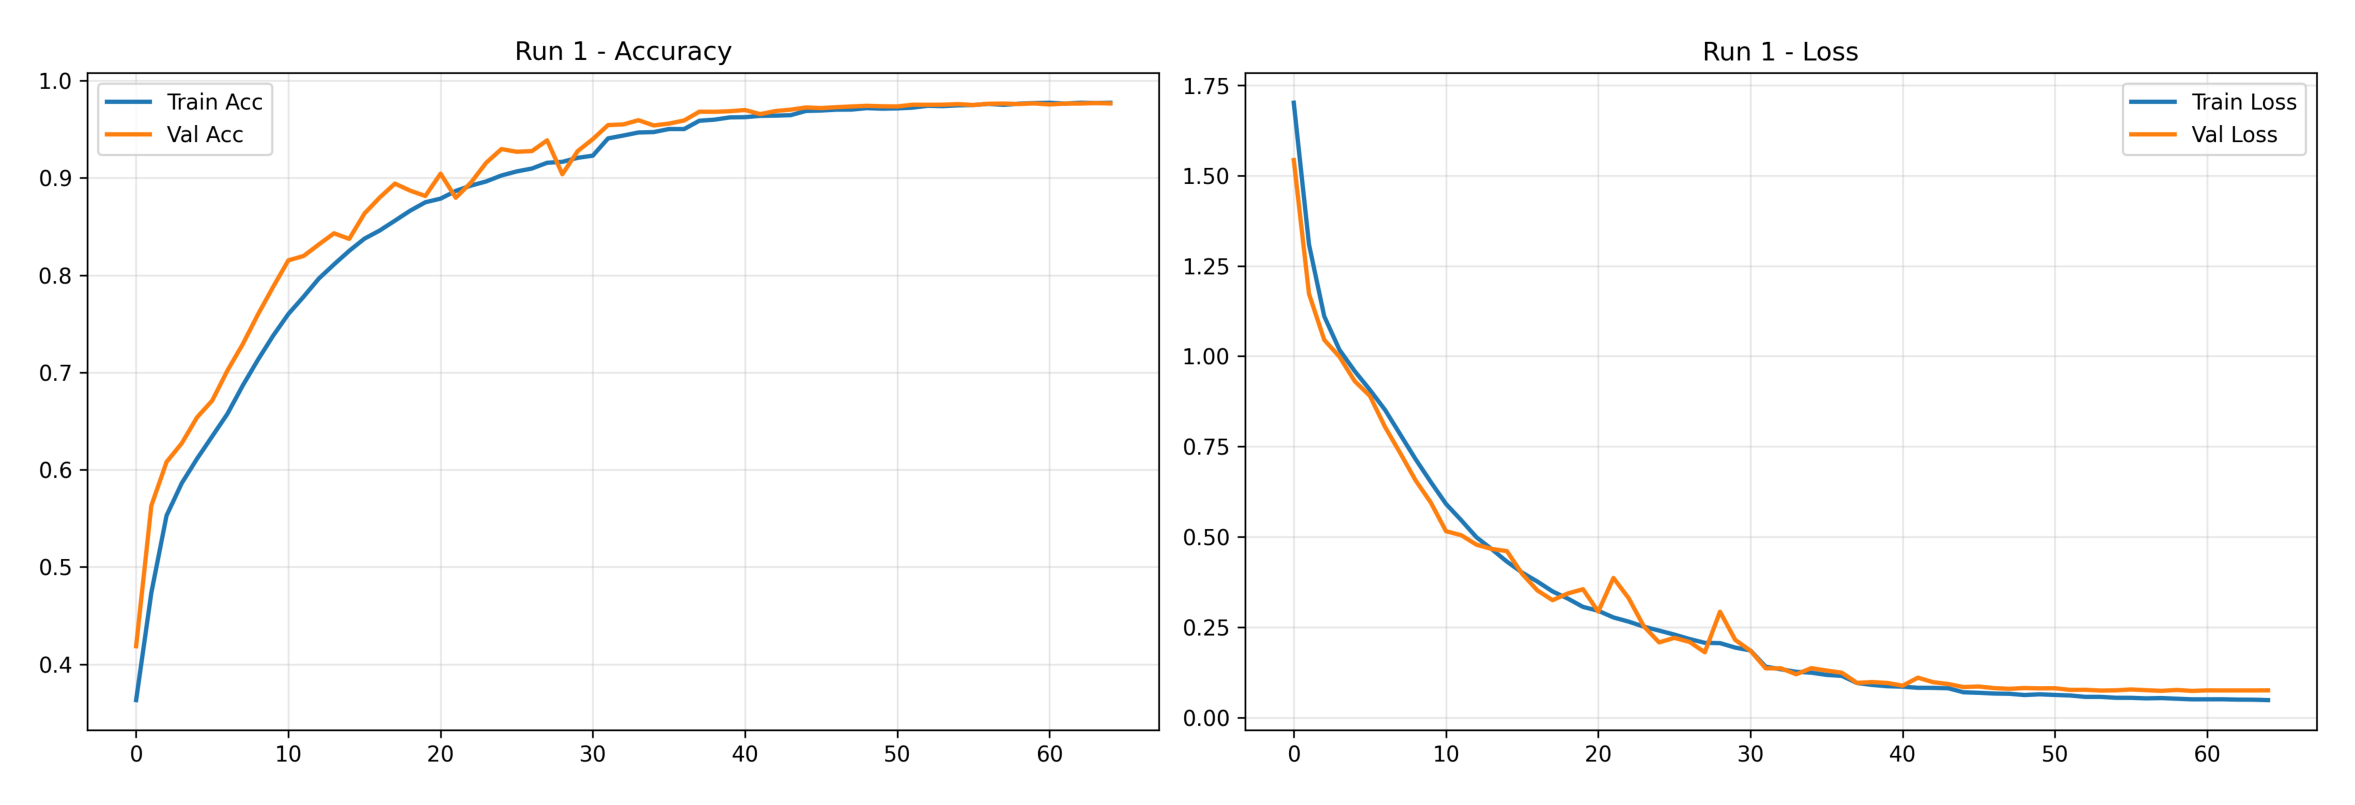

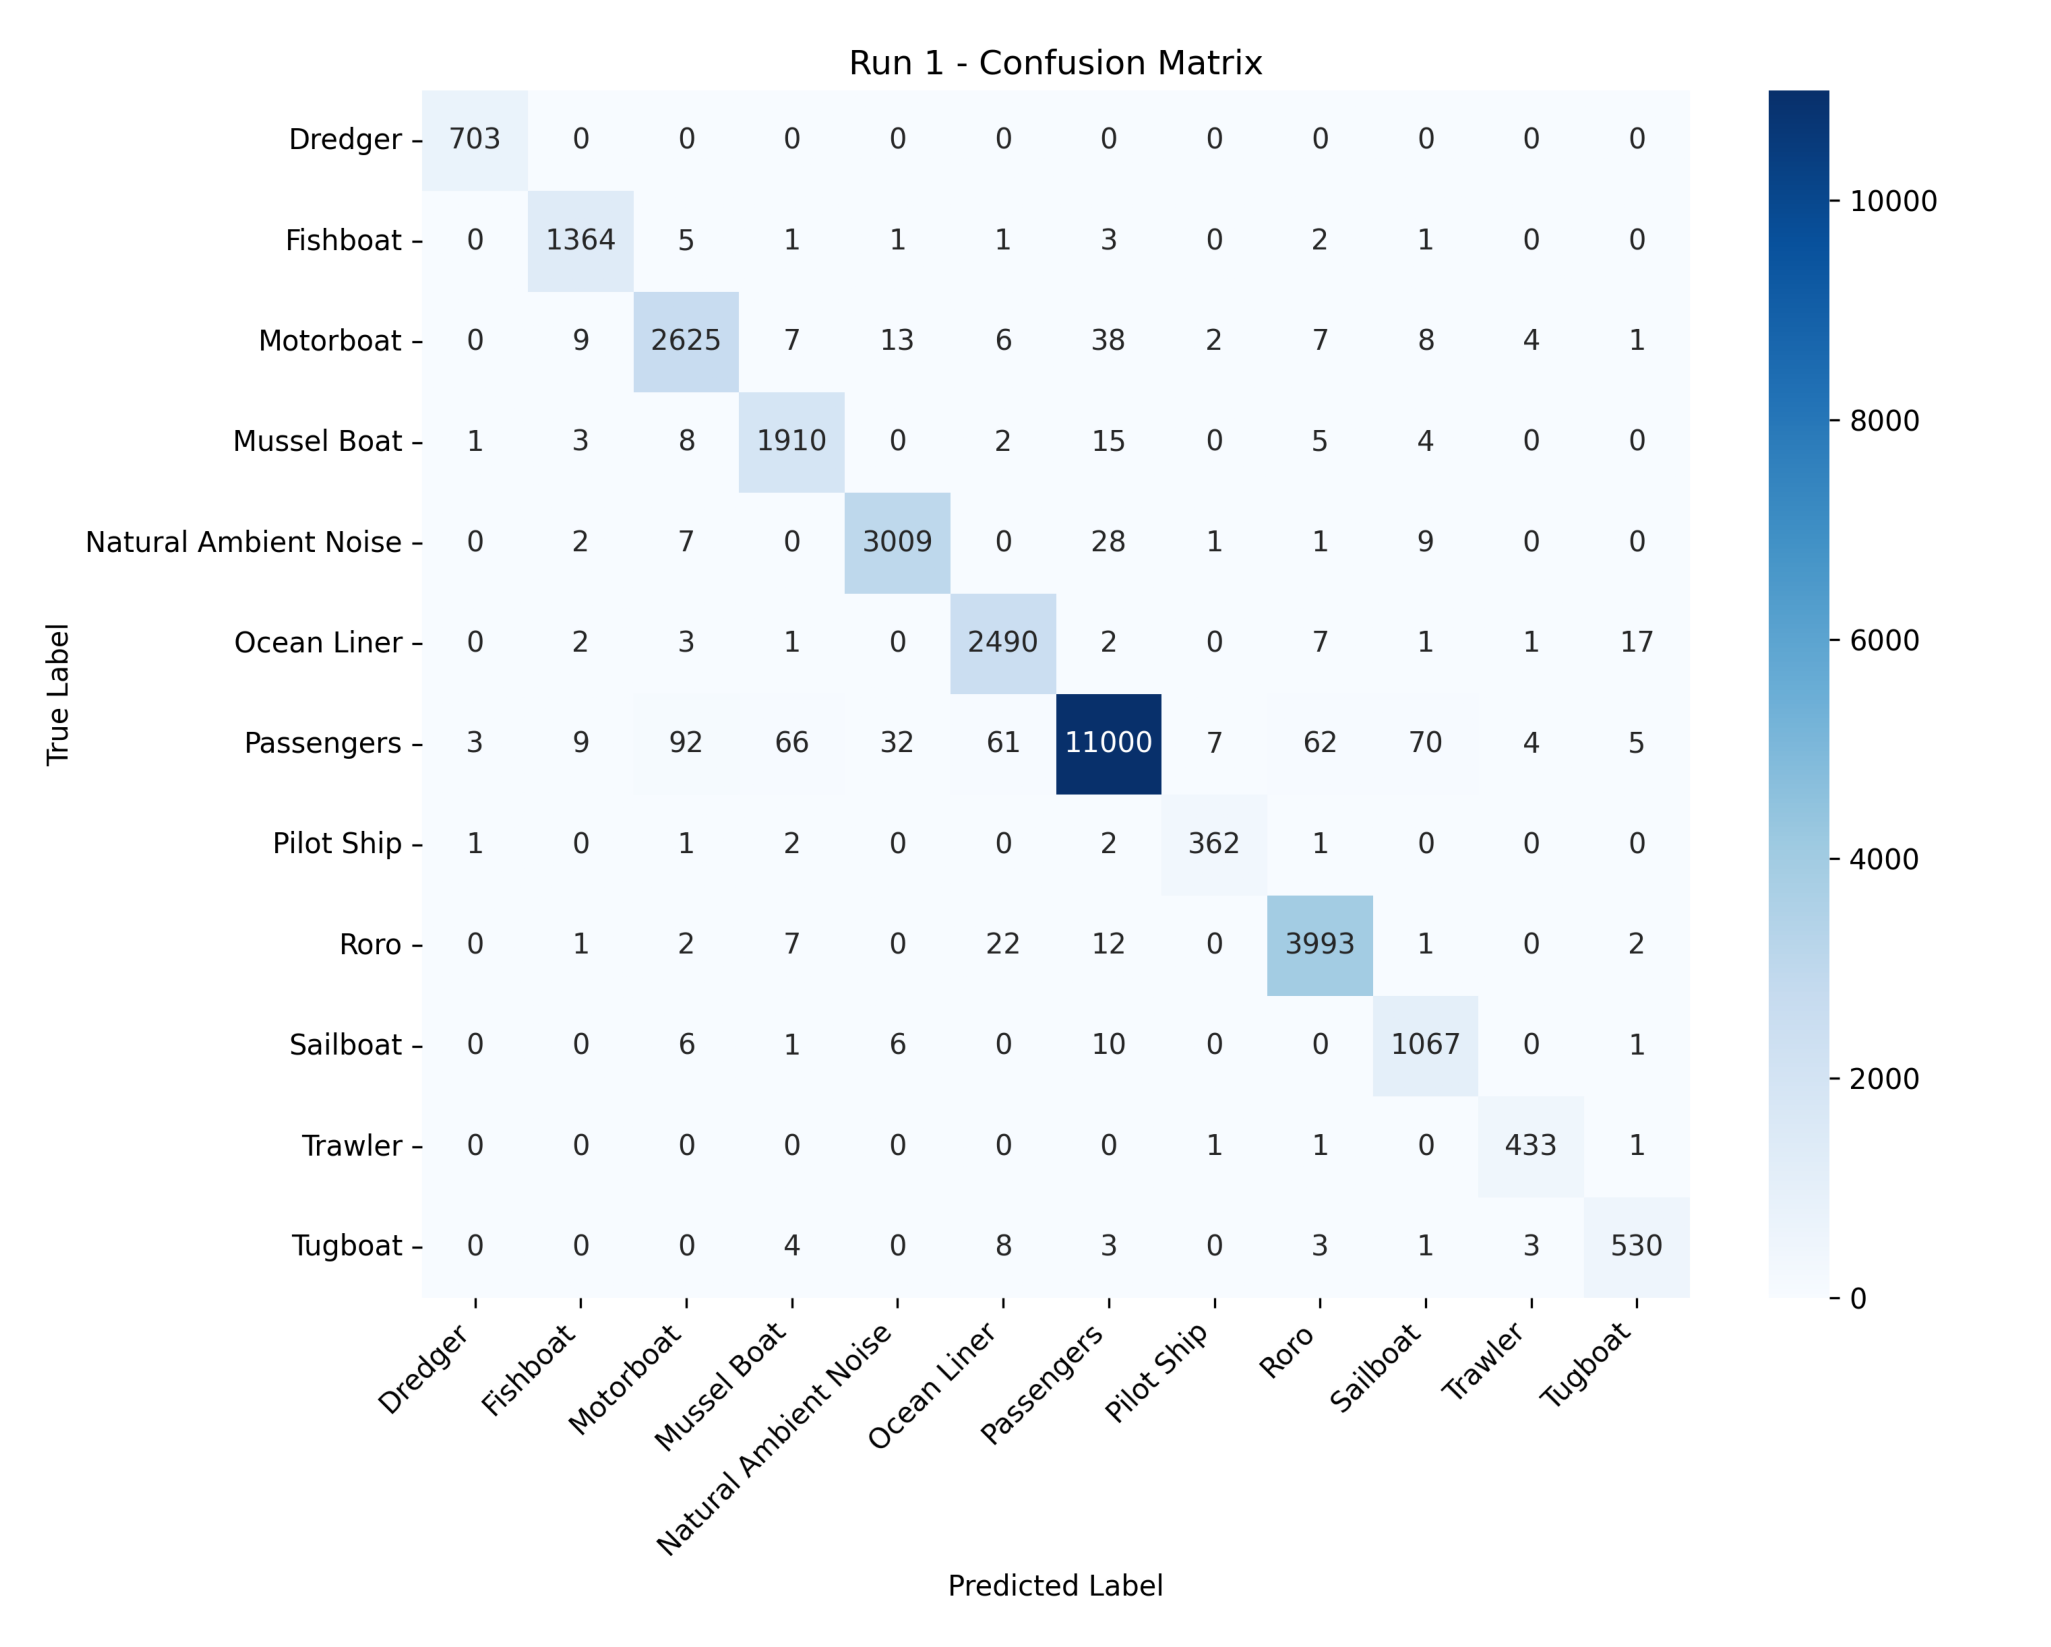



🌟 RESULTS FOR RUN_02 🌟
=== RUN 2 EVALUATION ===
Overall Accuracy: 96.57%
Overall Loss: 0.1058

                       precision    recall  f1-score   support

              Dredger     0.9957    0.9972    0.9964       703
             Fishboat     0.9804    0.9797    0.9800      1378
            Motorboat     0.9330    0.9518    0.9423      2720
          Mussel Boat     0.9496    0.9482    0.9489      1948
Natural Ambient Noise     0.9739    0.9905    0.9822      3057
          Ocean Liner     0.9491    0.9822    0.9653      2524
           Passengers     0.9852    0.9527    0.9687     11411
           Pilot Ship     0.9550    0.9783    0.9665       369
                 Roro     0.9590    0.9903    0.9744      4040
             Sailboat     0.9092    0.9551    0.9316      1091
              Trawler     0.9045    0.9771    0.9394       436
              Tugboat     0.9822    0.9004    0.9395       552

             accuracy                         0.9657     30229
            macro a

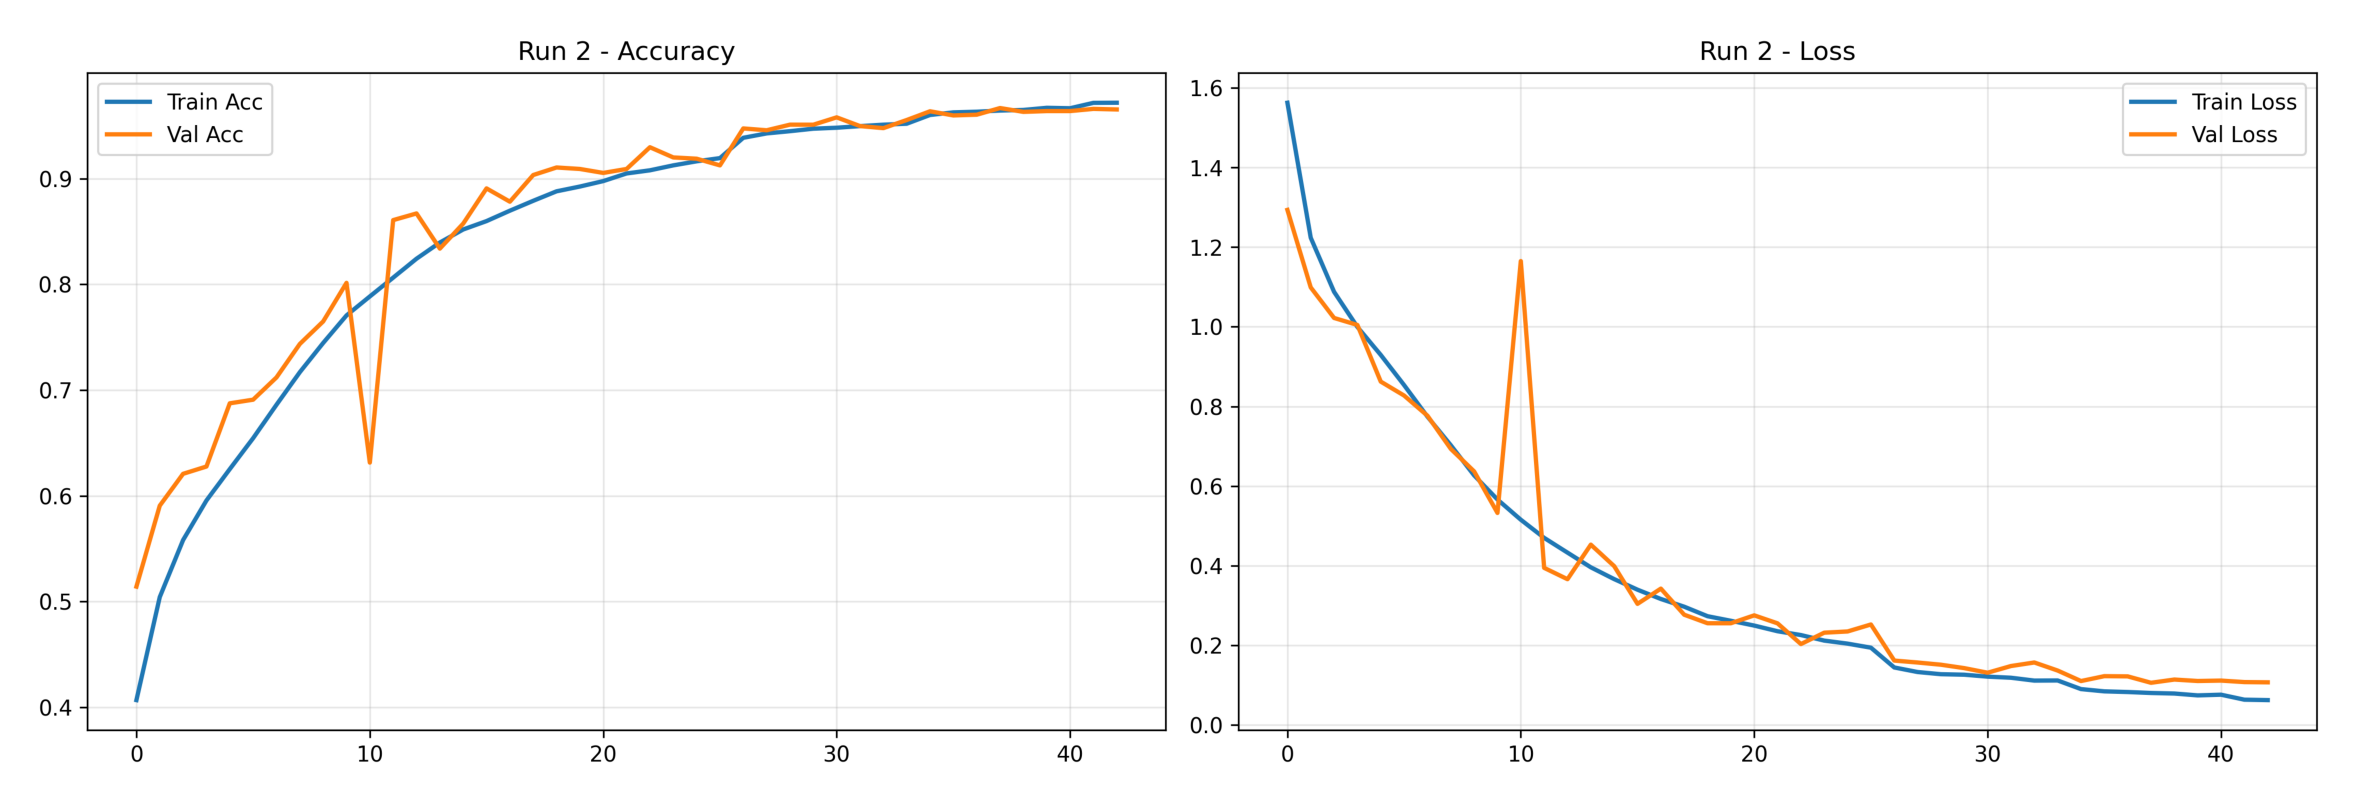

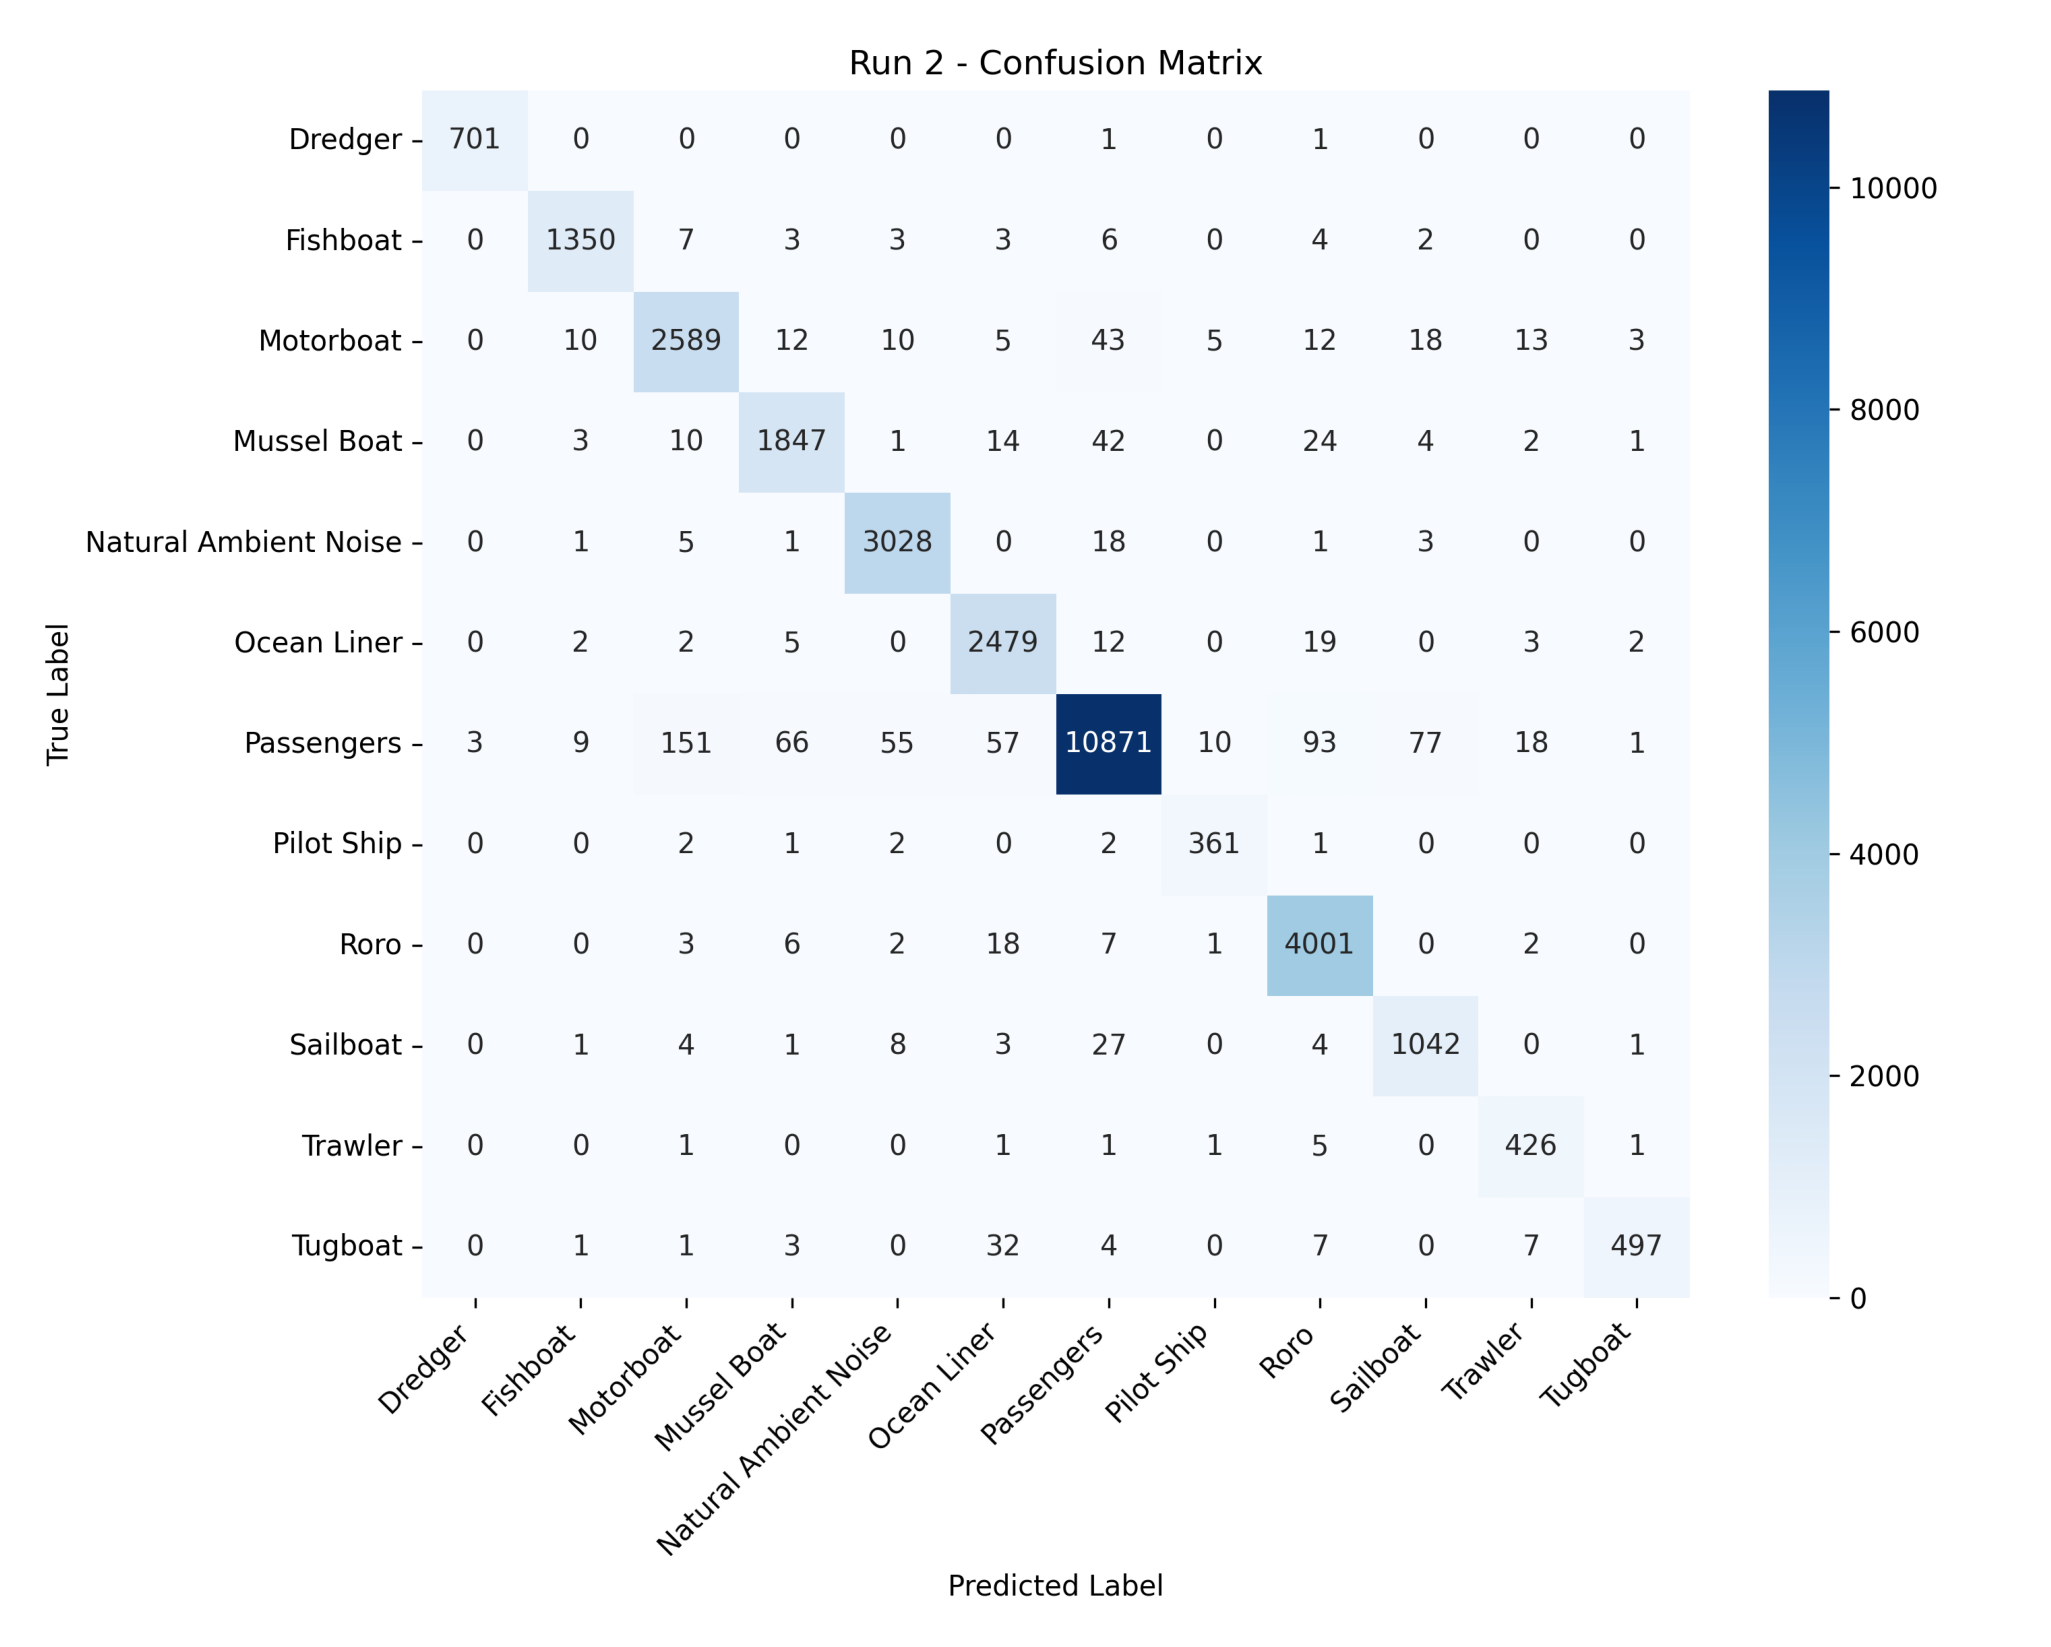



🌟 RESULTS FOR RUN_03 🌟
=== RUN 3 EVALUATION ===
Overall Accuracy: 96.64%
Overall Loss: 0.0991

                       precision    recall  f1-score   support

              Dredger     0.9901    0.9972    0.9936       703
             Fishboat     0.9559    0.9920    0.9736      1378
            Motorboat     0.9523    0.9393    0.9458      2720
          Mussel Boat     0.9593    0.9440    0.9516      1948
Natural Ambient Noise     0.9757    0.9869    0.9813      3057
          Ocean Liner     0.9612    0.9727    0.9669      2524
           Passengers     0.9803    0.9574    0.9687     11411
           Pilot Ship     0.9654    0.9837    0.9745       369
                 Roro     0.9662    0.9824    0.9742      4040
             Sailboat     0.8916    0.9725    0.9303      1091
              Trawler     0.9387    0.9839    0.9608       436
              Tugboat     0.9333    0.9638    0.9483       552

             accuracy                         0.9664     30229
            macro a

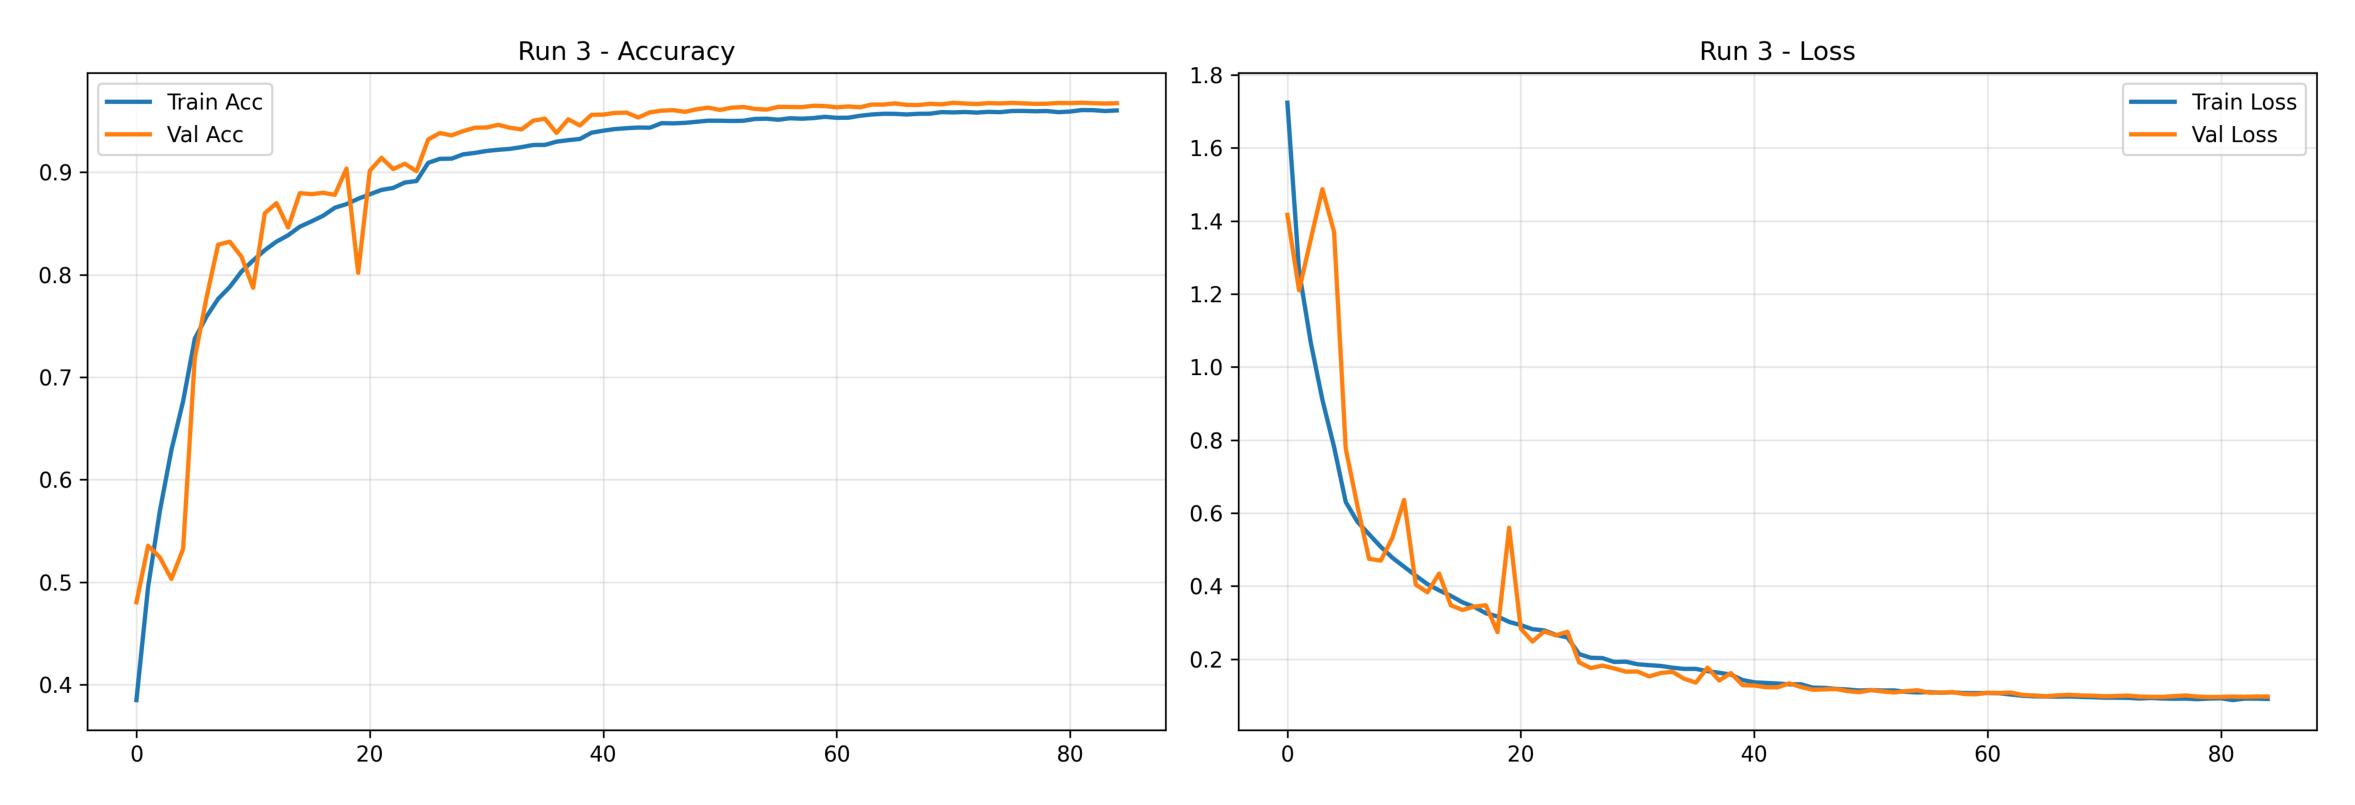

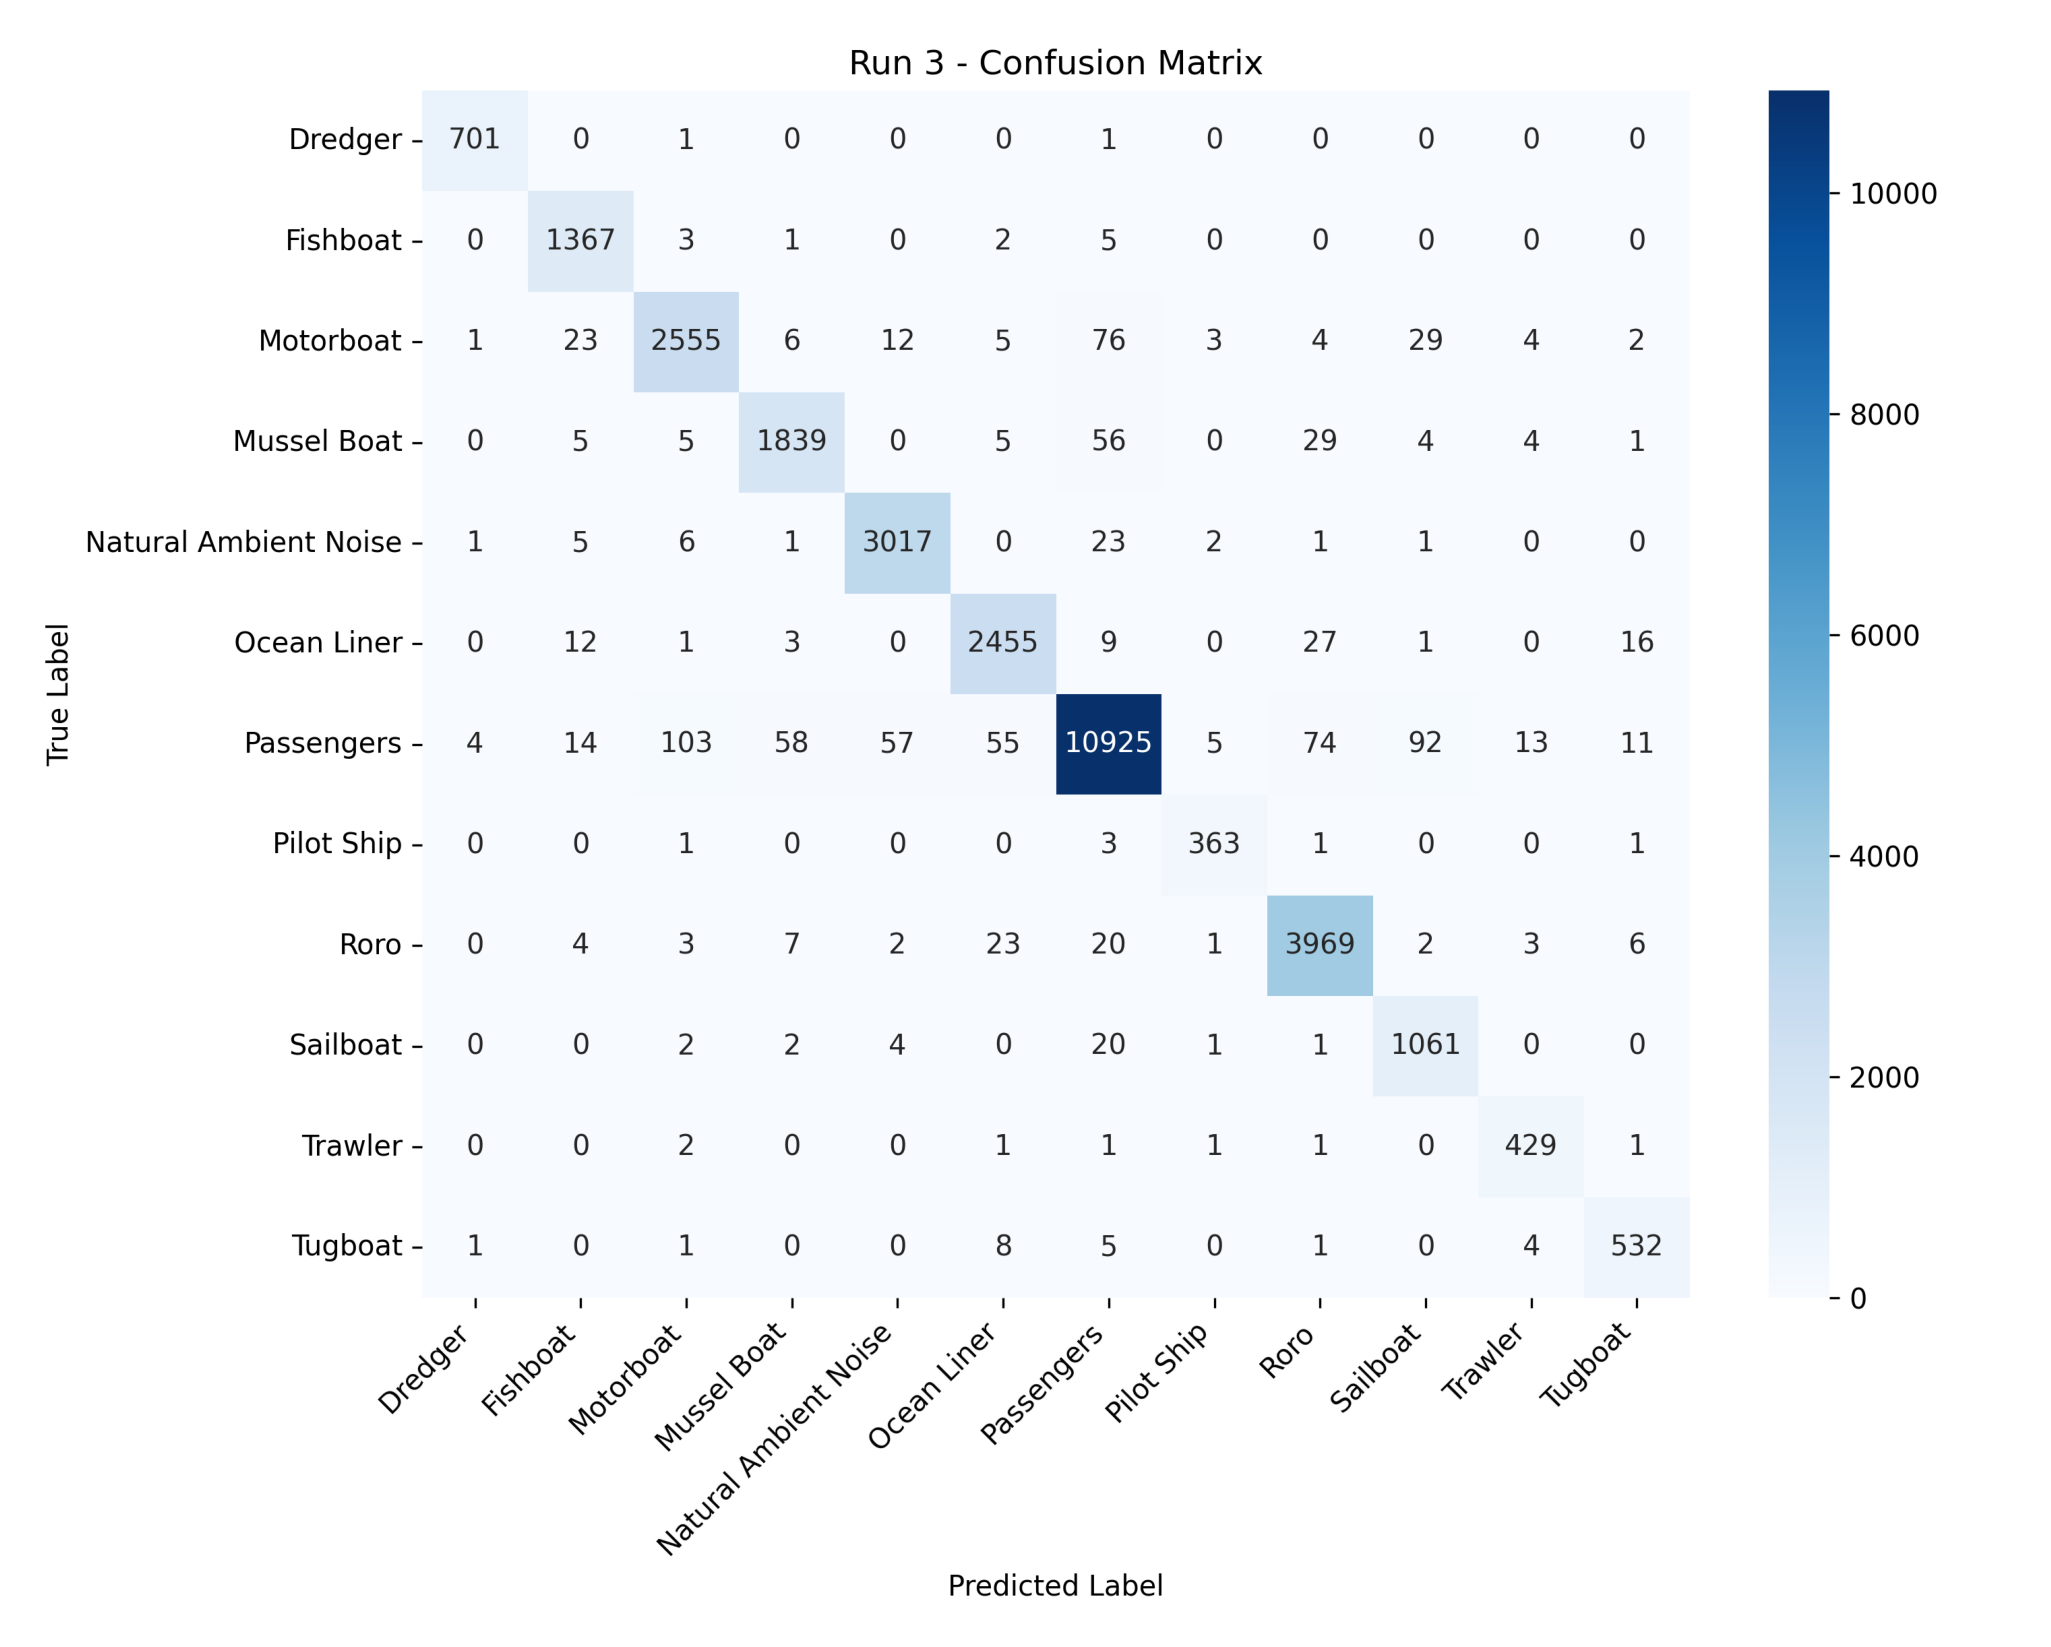



🌟 RESULTS FOR RUN_04 🌟
=== RUN 4 EVALUATION ===
Overall Accuracy: 96.74%
Overall Loss: 0.1016

                       precision    recall  f1-score   support

              Dredger     0.9929    0.9972    0.9950       703
             Fishboat     0.9840    0.9819    0.9829      1378
            Motorboat     0.9383    0.9507    0.9445      2720
          Mussel Boat     0.9440    0.9610    0.9524      1948
Natural Ambient Noise     0.9910    0.9755    0.9832      3057
          Ocean Liner     0.9506    0.9842    0.9671      2524
           Passengers     0.9847    0.9557    0.9700     11411
           Pilot Ship     0.9731    0.9810    0.9771       369
                 Roro     0.9539    0.9844    0.9689      4040
             Sailboat     0.9218    0.9725    0.9465      1091
              Trawler     0.9596    0.9817    0.9705       436
              Tugboat     0.9270    0.9656    0.9459       552

             accuracy                         0.9674     30229
            macro a

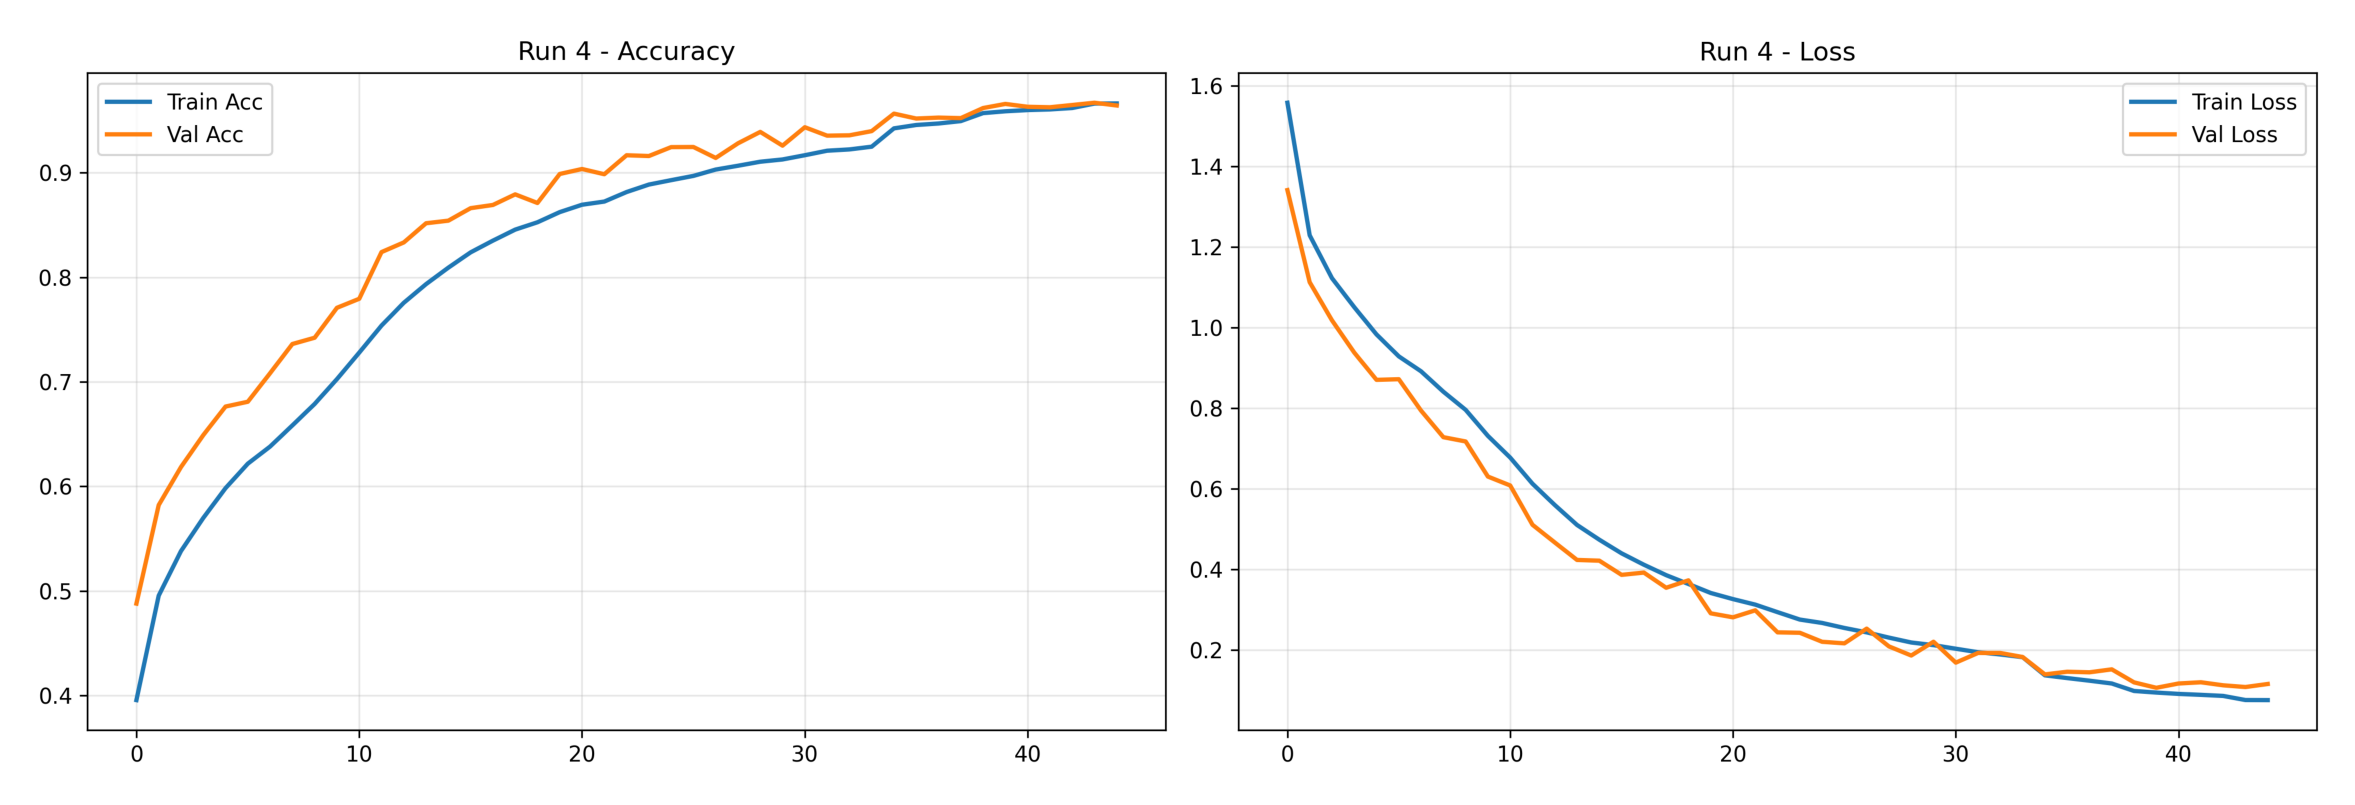

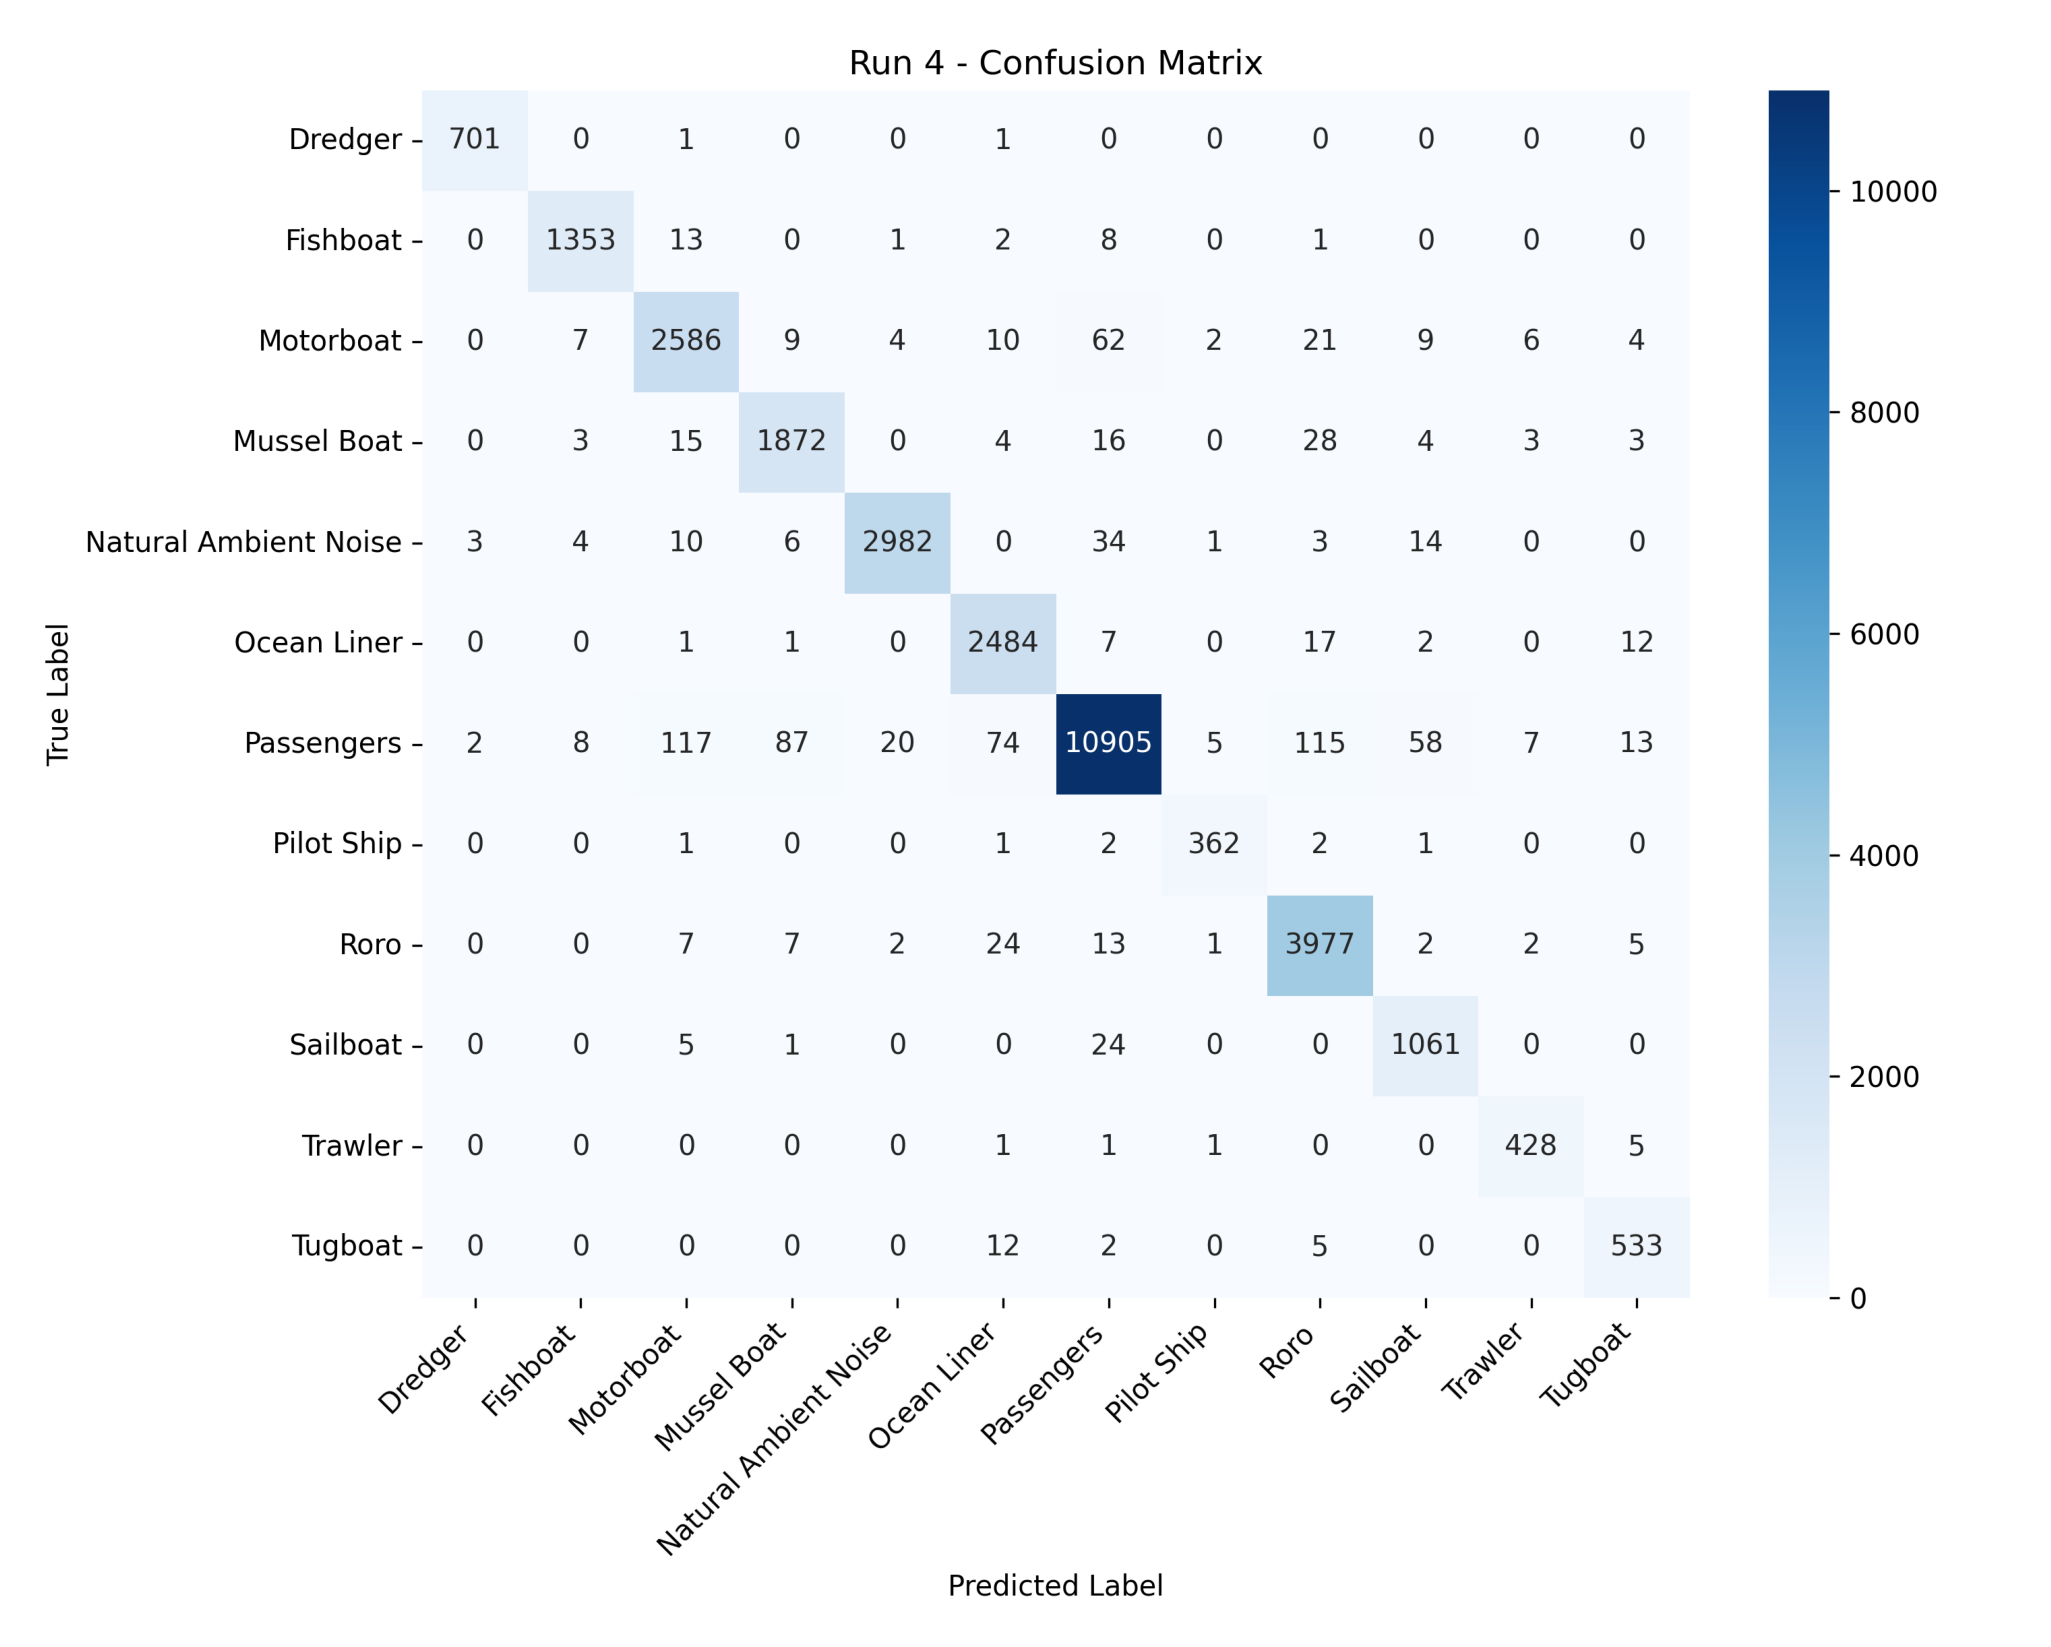



🌟 RESULTS FOR RUN_05 🌟
=== RUN 5 EVALUATION ===
Overall Accuracy: 98.08%
Overall Loss: 0.0615

                       precision    recall  f1-score   support

              Dredger     1.0000    0.9972    0.9986       703
             Fishboat     0.9835    0.9956    0.9895      1378
            Motorboat     0.9671    0.9721    0.9696      2720
          Mussel Boat     0.9733    0.9748    0.9741      1948
Natural Ambient Noise     0.9908    0.9836    0.9872      3057
          Ocean Liner     0.9788    0.9873    0.9830      2524
           Passengers     0.9878    0.9768    0.9822     11411
           Pilot Ship     0.9734    0.9919    0.9826       369
                 Roro     0.9796    0.9884    0.9840      4040
             Sailboat     0.9378    0.9817    0.9592      1091
              Trawler     0.9749    0.9817    0.9783       436
              Tugboat     0.9655    0.9620    0.9637       552

             accuracy                         0.9808     30229
            macro a

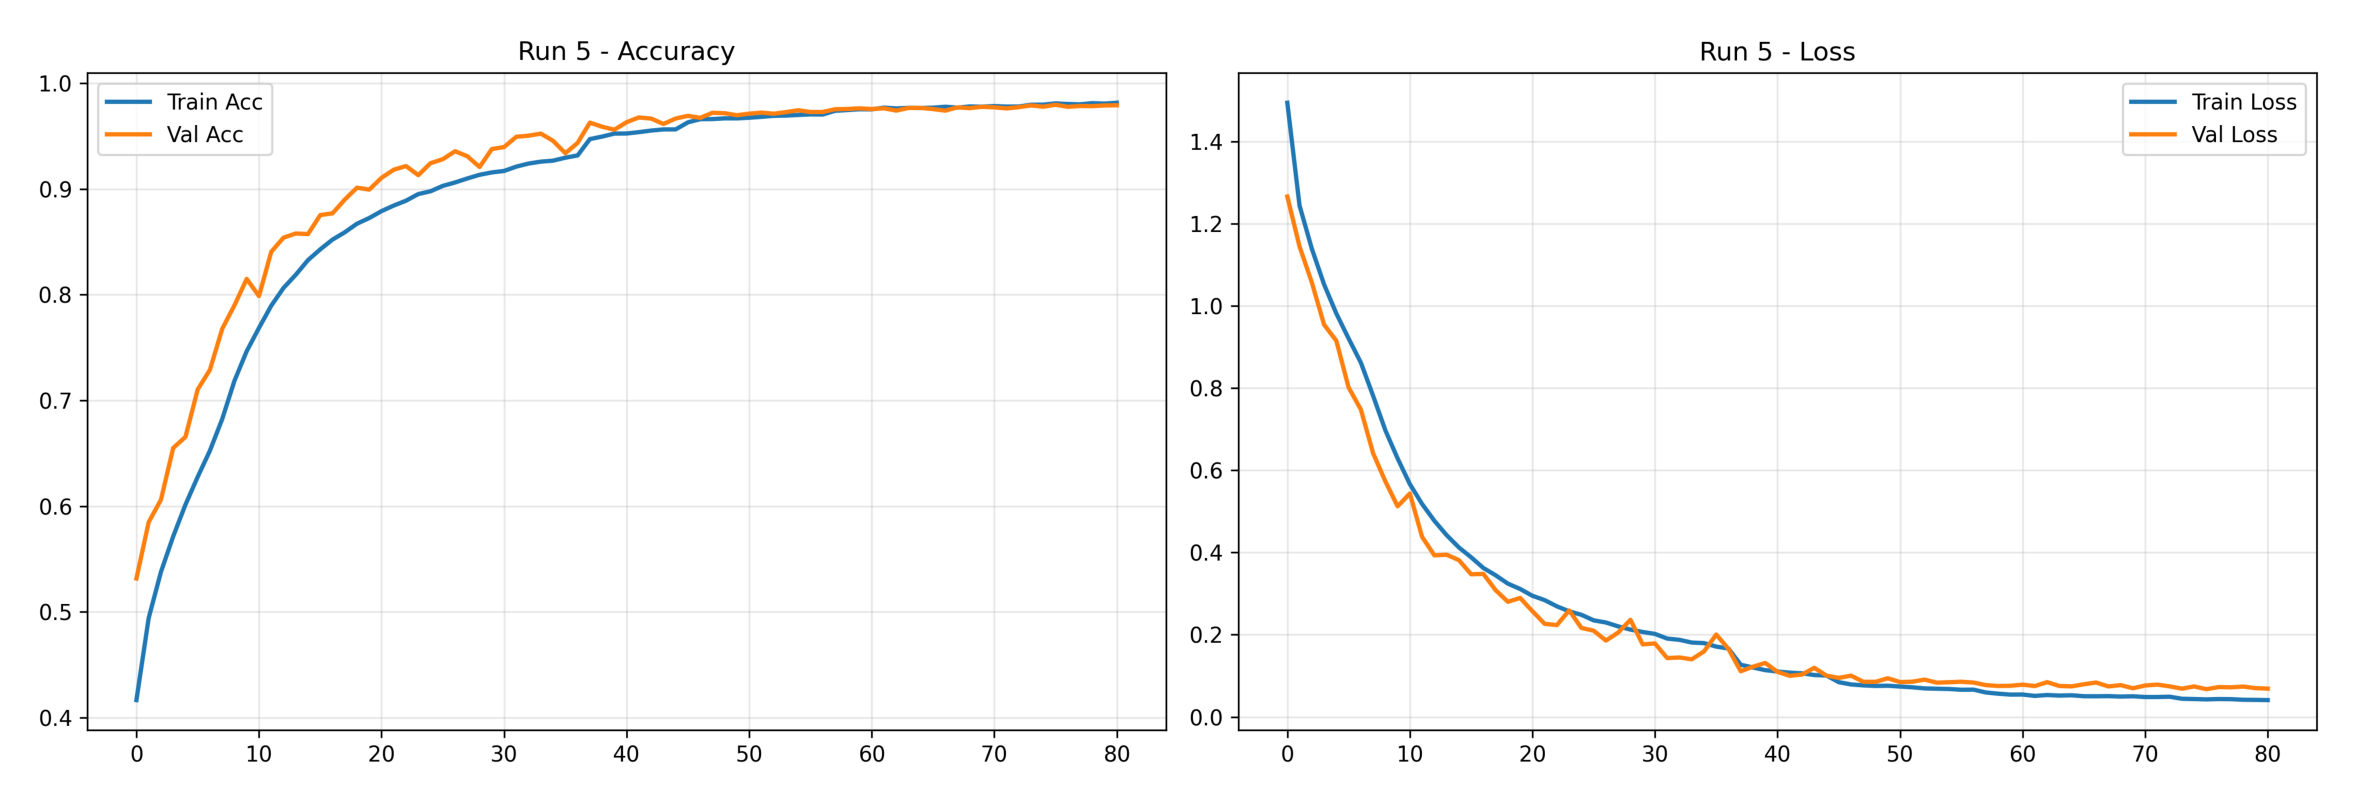

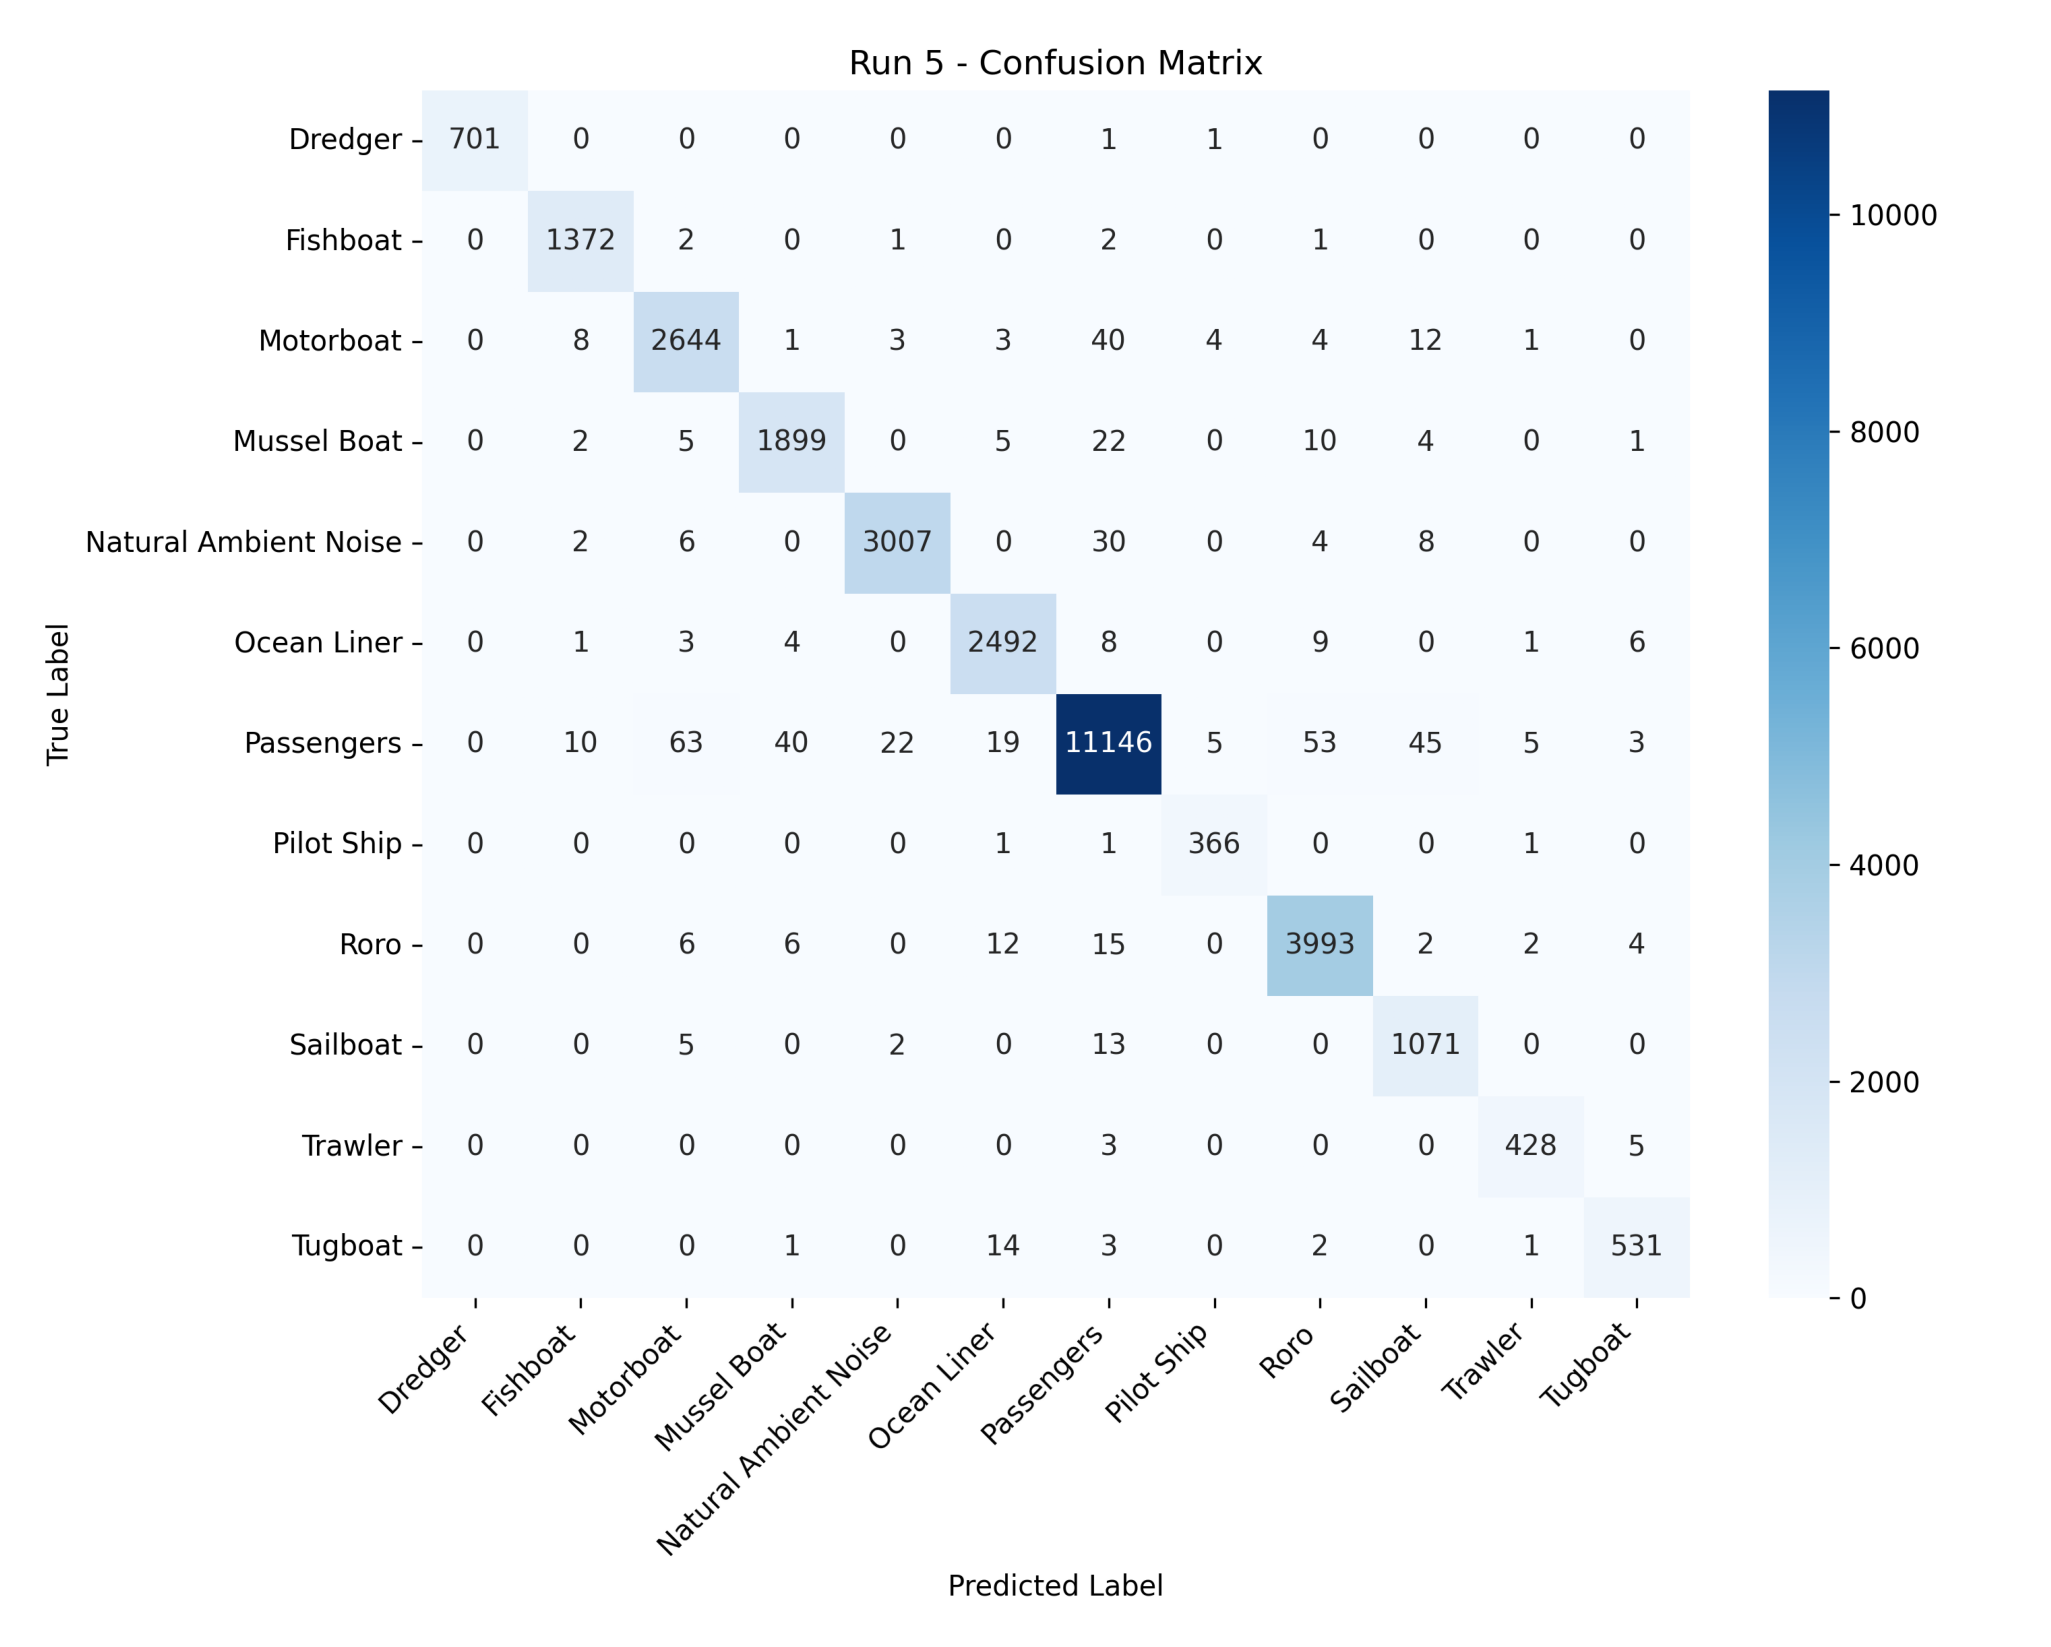

In [14]:
# ==============================================================================
# CELL 18: VISUALIZE ALL 5-RUN ARTIFACTS (LARGE IMAGES)
# ==============================================================================
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("="*80)
print("📈 VISUALIZING 5-RUN CROSS-VALIDATION RESULTS 📈")
print("="*80)

# Loop through all 5 saved run directories
for run in range(1, NUM_RUNS + 1):
    run_folder = f"Run_{run:02d}"
    run_path = os.path.join(run_save_dir, run_folder)

    print(f"\n\n{'='*60}")
    print(f"🌟 RESULTS FOR {run_folder.upper()} 🌟")
    print(f"{'='*60}")

    # 1. Print the Classification Report
    log_file = os.path.join(run_path, 'evaluation_log.txt')
    if os.path.exists(log_file):
        with open(log_file, 'r') as f:
            print(f.read())
    else:
        print(f"Could not find log file for {run_folder}")

    # 2. Display the Plots sequentially at maximum size
    hist_img = os.path.join(run_path, 'training_history.png')
    cm_img = os.path.join(run_path, 'confusion_matrix.png')

    if os.path.exists(hist_img) and os.path.exists(cm_img):
        # Display Training History (Massive)
        plt.figure(figsize=(20, 10), dpi=150)
        img1 = mpimg.imread(hist_img)
        plt.imshow(img1)
        plt.axis('off')
        plt.show()

        # Display Confusion Matrix (Massive)
        plt.figure(figsize=(20, 14), dpi=150)
        img2 = mpimg.imread(cm_img)
        plt.imshow(img2)
        plt.axis('off')
        plt.show()
    else:
        print(f"Could not find plot images for {run_folder}")